# Consumo de eletricidade na China — estudo completo de séries temporais
**Econometria II · 2015–2024 · análise preparada em 11/09/2026**

Este notebook explica e executa: estatística descritiva, remoção e reposição de observações, testes de estacionariedade, identificação e tratamento de outliers, médias móveis, decomposição em tendência/sazonalidade/ciclo e suavização de Holt e Holt-Winters.

**Ideia central:** uma série temporal é uma sequência de valores em ordem de tempo. Aqui, cada valor é a eletricidade consumida na China em um mês. A ordem importa: agosto de 2020 pode se parecer tanto com julho de 2020 quanto com agosto de outros anos.

## Roteiro
1. Dados e estatística descritiva.
2. Experimento de imputação: apagar valores conhecidos, repor e medir o erro.
3. Preparação de uma série de trabalho completa.
4. Testes ADF e KPSS de estacionariedade.
5. Outliers reais suspeitos e experimento com erros artificiais.
6. Média móvel e decomposição: tendência, sazonalidade, ciclo e resíduo.
7. Holt e Holt-Winters: funcionamento, ajuste e comparação fora da amostra.
8. Conclusões automáticas e arquivos de resultados.

A ordem começa pelo preenchimento porque vários métodos exigem uma série sem lacunas. **Isso não transforma estimativas em observações reais.** As máscaras de procedência são mantidas em todas as etapas.

### Como executar
Mantenha este notebook junto à pasta `dados/energia_china`. Use Python com `numpy`, `pandas`, `scipy`, `statsmodels`, `matplotlib` e `IPython`; execute as células na ordem. Não é necessário acesso à internet: os dados da coleta anterior estão salvos. As tabelas e figuras já estão incorporadas ao notebook. Para refazer a coleta original, consulte `coletar_energia_china.py` e o notebook descritivo anterior.

In [1]:
from pathlib import Path
import json
import hashlib
import inspect
import warnings
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import statsmodels
from scipy.interpolate import PchipInterpolator
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing
from IPython.display import display, Markdown

RAIZ = Path.cwd()
BASE = RAIZ / 'dados/energia_china'
SAIDA = RAIZ / 'resultados/energia_china'
FIG = SAIDA / 'figuras'
FIG.mkdir(parents=True, exist_ok=True)
SEMENTE = 20260911
plt.rcParams.update({'figure.figsize': (12, 4.5), 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.max_columns', 16)
pd.set_option('display.width', 150)

def tabela(df, nome, casas=3):
    df.to_csv(SAIDA / (nome + '.csv'), index=True)
    display(df.round(casas))

def figura(nome):
    plt.gcf().tight_layout()
    plt.gcf().savefig(FIG / (nome + '.png'), dpi=150, bbox_inches='tight')
    plt.show()

print('Versões:', {'Python': sys.version.split()[0], 'pandas': pd.__version__,
                   'numpy': np.__version__, 'scipy': scipy.__version__,
                   'statsmodels': statsmodels.__version__})
print('Semente aleatória:', SEMENTE)

Versões: {'Python': '3.13.9', 'pandas': '2.3.3', 'numpy': '2.5.3', 'scipy': '1.18.1', 'statsmodels': '0.15.0'}
Semente aleatória: 20260911


## 1. Dados: o que estamos medindo?
A **National Energy Administration (NEA)** divulga o indicador **全社会用电量**, consumo de eletricidade de toda a sociedade. Esta é uma fonte oficial adequada para **eletricidade**; consumo total de energia, incluindo combustíveis, é outro indicador, divulgado também pelo NBS.

- Unidade original: 100 milhões de kWh. Dividimos por 10 para obter **TWh** (bilhões de kWh).
- Frequência: **mensal**, com sazonalidade anual sugerida pelos dados. Um ano corresponde a 12 observações.
- Natureza: variável quantitativa contínua, de **fluxo**: soma da energia consumida durante o mês.
- Grade: janeiro/2015 a dezembro/2024, 120 meses.
- Coleta anterior: 99 valores diretamente publicados, 9 janeiros reconstituídos como bimestre menos fevereiro no mesmo boletim e 12 lacunas.

Os 12 meses sem valor separado na coleta são os dez dezembros e janeiro/fevereiro de 2024. Isso **não significa consumo zero**. Janeiro–fevereiro de 2024 totaliza 1.531,6 TWh, mas a divisão não foi localizada. Os acumulados de boletins diferentes apresentam pequenas divergências; não serão usados para reconstruir automaticamente meses nem para revelar valores apagados no experimento.

**Fontes:** [arquivo NEA](https://www.nea.gov.cn/sjzz/ghs/zjgx.htm), [bimestre de 2024](https://www.nea.gov.cn/2024-03/20/c_1310768302.htm), [total anual de 2024](https://www.nea.gov.cn/20250120/4f7f249bac714e7693adecac996d742f/c.html), [NBS: consumo total de energia](https://www.stats.gov.cn/english/PressRelease/202502/t20250228_1958822.html). Maio/2023 vem de [republicação que atribui os números à NEA](https://obor.nea.gov.cn/detail/19346.html). As URLs de cada valor estão no CSV original.

In [2]:
dados = pd.read_csv(BASE / 'consumo_eletricidade_china_mensal.csv', parse_dates=['data']).set_index('data').sort_index()
serie = dados.valor_twh.asfreq('MS').copy()
diretos = dados.observado_direto_twh.notna().reindex(serie.index)
reconstituidos = dados.status.eq('reconstituido_mesma_fonte')
lacunas_originais = serie.isna()
assert serie.index.equals(pd.date_range('2015-01-01', '2024-12-01', freq='MS'))
assert serie.index.is_unique and serie.count() == 108
assert diretos.sum() == 99 and lacunas_originais.sum() == 12
assert (serie.dropna() > 0).all()
extraidos = pd.read_csv(BASE / 'valores_extraidos.csv')
anuais = extraidos[extraidos.tipo.eq('anual')].set_index('ano').valor_twh.sort_index()
print('SHA-256 do CSV:', hashlib.sha256((BASE / 'consumo_eletricidade_china_mensal.csv').read_bytes()).hexdigest())
tabela(dados[['valor_twh', 'status']], '01_serie_e_procedencia')

SHA-256 do CSV: 90fefa90ff97057dfe549c0ec05c95f7ce3795eca1c3a03995a23b6ea11a53c2


,valor_twh,status
data,,
2015-01-01,485.9,reconstituido_mesma_fonte
2015-02-01,359.5,observado_mensal
2015-03-01,444.8,observado_mensal
2015-04-01,441.5,observado_mensal
2015-05-01,456.7,observado_mensal
...,...,...
2024-08-01,964.9,observado_mensal
2024-09-01,847.5,observado_mensal
2024-10-01,774.2,observado_mensal


### Estatística descritiva em palavras simples
A **média** é a soma dividida pela quantidade de valores; a **mediana** é o valor central depois de ordenar. Os **quartis** delimitam os 25%, 50% e 75% da distribuição. O **desvio-padrão** mede a dispersão em torno da média; a **variância** é seu quadrado. O **coeficiente de variação**, $100s/\bar y$, compara o desvio-padrão com a média em porcentagem. **Assimetria** indica desequilíbrio entre as caudas e **excesso de curtose** descreve a forma das caudas em relação à normal (referência zero).

Abaixo, usamos somente os 108 valores disponíveis, sem preencher nada. A soma é **parcial**, não o consumo de dez anos completos. As medidas misturam meses sazonais e anos com níveis diferentes: não são medidas de uma distribuição invariável no tempo.

,Valor
N disponível,108.000
Média (TWh),617.927
Mediana (TWh),600.750
Desvio-padrão amostral (TWh),127.493
Variância amostral (TWh²),16254.462
Mínimo (TWh),359.500
Q1 (TWh),512.850
Q3 (TWh),697.075
Máximo (TWh),964.900
Amplitude (TWh),605.400


,count,mean,median,std,Total anual NEA (TWh)
data,,,,,
2015,11,458.882,456.7,40.359,5550.0
2016,11,489.355,492.5,47.962,5919.8
2017,11,521.582,513.9,47.067,6307.7
2018,11,565.145,564.7,55.782,6844.9
2019,11,592.227,591.2,51.876,7225.5
2020,11,606.864,617.2,76.994,7511.0
2021,11,681.545,672.4,67.444,8312.8
2022,11,713.982,694.4,72.438,8637.2
2023,11,760.782,741.9,70.494,9224.1


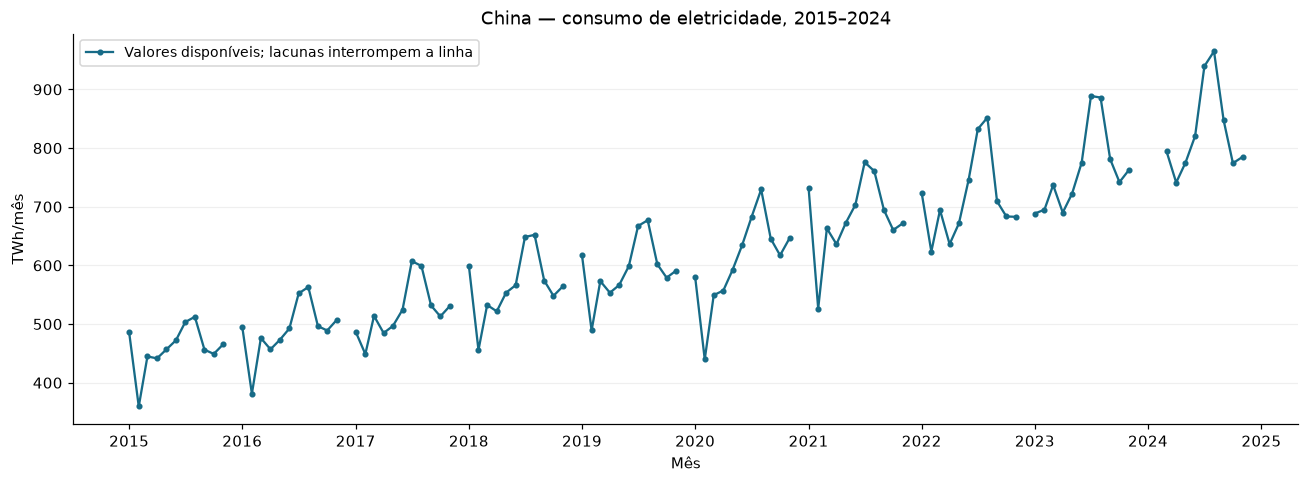

In [3]:
x = serie.dropna()
descritiva = pd.Series({'N disponível': x.count(), 'Média (TWh)': x.mean(), 'Mediana (TWh)': x.median(),
    'Desvio-padrão amostral (TWh)': x.std(ddof=1), 'Variância amostral (TWh²)': x.var(ddof=1),
    'Mínimo (TWh)': x.min(), 'Q1 (TWh)': x.quantile(.25), 'Q3 (TWh)': x.quantile(.75),
    'Máximo (TWh)': x.max(), 'Amplitude (TWh)': x.max()-x.min(), 'CV (%)': 100*x.std()/x.mean(),
    'Assimetria': x.skew(), 'Excesso de curtose': x.kurt(), 'Soma parcial (TWh)': x.sum()}, name='Valor').to_frame()
tabela(descritiva, '02_descritiva_original')
resumo_anual = serie.groupby(serie.index.year).agg(['count','mean','median','std'])
resumo_anual['Total anual NEA (TWh)'] = anuais
tabela(resumo_anual, '03_descritiva_anual')
fig, ax = plt.subplots()
ax.plot(serie, '.-', color='#176B87', label='Valores disponíveis; lacunas interrompem a linha')
ax.set(title='China — consumo de eletricidade, 2015–2024', ylabel='TWh/mês', xlabel='Mês')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=.2)
figura('01_serie_original')

## 2. Eliminar observações e comparar métodos de reposição
**Imputar** significa estimar um valor que falta. Para saber se um método funciona, guardamos uma resposta conhecida, apagamos sua cópia de entrada e pedimos ao método para reconstruí-la. Só depois comparamos com a resposta guardada.

### Métodos comparados
| Método | Como funciona | Limitação |
|---|---|---|
| Média global | Coloca a média dos valores visíveis em cada lacuna. | Ignora crescimento e época do ano; referência simples. |
| Interpolação linear | Liga dois pontos visíveis por uma reta. | Pode apagar picos; nas pontas usamos o valor visível mais próximo. |
| PCHIP | Liga pontos por curvas cúbicas que preservam a forma local. | Não aprende o padrão anual; nas pontas também usa o valor mais próximo. |
| Regressão harmônica no log | Ajusta crescimento e ondas anuais aos valores visíveis. | Supõe crescimento aproximadamente exponencial e sazonalidade relativamente estável. |
| Harmônica + resíduo local | Ajusta o modelo anterior e interpola o que ele não explicou entre vizinhos. | Pode transportar choques locais para a lacuna. |

Para a interpolação linear, entre os meses $a$ e $b$:
$$\widehat y_t=y_a+\frac{t-a}{b-a}(y_b-y_a).$$
Usamos **posição mensal** (janeiro, fevereiro, março…), e não distância em dias.

Na regressão harmônica, modelamos:
$$\log y_t=\beta_0+\beta_1(t/12)+\sum_{k=1}^{3}\left[a_k\sin(2\pi kt/12)+b_k\cos(2\pi kt/12)\right]+e_t.$$
As ondas são chamadas de **termos de Fourier**: somadas, desenham um padrão que se repete a cada 12 meses. Três harmônicos permitem um desenho mais flexível que uma única onda, sem criar uma variável livre para dezembro, que nunca foi observado. Ajustamos os coeficientes por mínimos quadrados somente nos pontos visíveis. Aplicar a exponencial devolve valores positivos em TWh; é uma previsão central na escala original, sem correção de viés lognormal.

No método híbrido, a previsão é $\exp(\widehat{\log y_t}+\widetilde e_t)$, com $\widetilde e_t$ obtido por interpolação linear dos resíduos visíveis. Nas pontas, mantemos o último resíduo disponível.

### Regras do experimento
- Seleção dos métodos **somente em 2015–2022**: 2023 e 2024 ficam disponíveis para a comparação preditiva ao final.
- Apagamos apenas valores **diretamente publicados**; uma estimativa nunca é usada como resposta verdadeira.
- Cenários: 10% e 20% dos valores diretos removidos aleatoriamente; um bloco de 3 ou 6 meses consecutivos removido por vez.
- Cada cenário é repetido 20 vezes, com sementes fixas. Os métodos recebem exatamente as mesmas máscaras em cada repetição.
- Se fevereiro for apagado, retiramos também o janeiro reconstituído a partir daquele boletim, evitando dependência indireta do valor escondido. Esse janeiro adicional não entra no cálculo do erro.
- Não usamos totais anuais, acumulados ou valores apagados para ajustar os métodos.
- Trata-se de **reconstrução retrospectiva**: usar vizinhos posteriores ao buraco é permitido. Isso é diferente de prever o futuro.

### Como medir o erro?
$$MAE=\frac1n\sum |y_t-\widehat y_t|,\qquad RMSE=\sqrt{\frac1n\sum(y_t-\widehat y_t)^2}.$$
**MAE** é o erro absoluto médio em TWh. **RMSE** penaliza mais os erros grandes. Em ambos, menor é melhor. O **MAPE** expressa o erro absoluto relativo em porcentagem; pode ser problemático perto de zero, o que não ocorre aqui.

In [4]:
METODOS = ['Média global', 'Linear', 'PCHIP', 'Harmônica log', 'Harmônica + resíduo']

def matriz_harmonica(n, k=3):
    t = np.arange(n, dtype=float)
    col = [np.ones(n), t/12]
    for j in range(1, k+1):
        col += [np.sin(2*np.pi*j*t/12), np.cos(2*np.pi*j*t/12)]
    return np.column_stack(col)

def imputar(s, metodo):
    s = s.astype(float).copy()
    ok = s.notna().to_numpy(); t = np.arange(len(s), dtype=float)
    assert ok.sum() >= 12 and (s.dropna() > 0).all()
    if metodo == 'Média global':
        estimativa = np.full(len(s), s.mean())
    elif metodo == 'Linear':
        estimativa = np.interp(t, t[ok], s.to_numpy()[ok])
    elif metodo == 'PCHIP':
        curva = PchipInterpolator(t[ok], s.to_numpy()[ok], extrapolate=False)
        estimativa = pd.Series(curva(t)).ffill().bfill().to_numpy()
    else:
        assert metodo in ['Harmônica log', 'Harmônica + resíduo']
        X = matriz_harmonica(len(s)); z = np.log(s.to_numpy()[ok])
        coef = np.linalg.lstsq(X[ok], z, rcond=None)[0]
        previsao_log = X @ coef
        if metodo == 'Harmônica + resíduo':
            residuo = z - previsao_log[ok]
            previsao_log += np.interp(t, t[ok], residuo)
        estimativa = np.exp(previsao_log)
    resultado = s.copy()
    resultado.iloc[np.flatnonzero(~ok)] = estimativa[~ok]
    assert resultado.notna().all() and (resultado > 0).all()
    np.testing.assert_array_equal(resultado[ok], s[ok])
    return resultado

def ocultar(s, datas):
    entrada = s.copy(); entrada.loc[datas] = np.nan
    for data in datas:
        janeiro = pd.Timestamp(data.year, 1, 1)
        if data.month == 2 and janeiro in entrada.index and reconstituidos.get(janeiro, False):
            entrada.loc[janeiro] = np.nan
    return entrada

def metricas(real, previsto):
    a = np.asarray(real, dtype=float); b = np.asarray(previsto, dtype=float)
    assert len(a) and np.isfinite(a).all() and np.isfinite(b).all()
    e = b-a
    return {'MAE': np.abs(e).mean(), 'RMSE': np.sqrt(np.mean(e**2)),
            'MAPE (%)': 100*np.mean(np.abs(e)/np.abs(a))}

periodo_experimento = serie.loc[:'2022-12-01']
elegiveis = diretos.reindex(periodo_experimento.index)

def sortear_mascara(s, elegivel, cenario, rng):
    candidatos = np.flatnonzero(elegivel.to_numpy())
    if cenario.startswith('Aleatório'):
        fracao = .1 if '10%' in cenario else .2
        pos = rng.choice(candidatos, size=max(1, round(fracao*len(candidatos))), replace=False)
    else:
        tamanho = 3 if '3 meses' in cenario else 6
        inicios = [i for i in range(len(s)-tamanho+1) if elegivel.iloc[i:i+tamanho].all()]
        inicio = rng.choice(inicios); pos = np.arange(inicio, inicio+tamanho)
    return s.index[np.sort(pos)]

CENARIOS = ['Aleatório 10%', 'Aleatório 20%', 'Bloco 3 meses', 'Bloco 6 meses']
registros = []; detalhes = []
for repeticao in range(20):
    for c, cenario in enumerate(CENARIOS):
        rng = np.random.default_rng(SEMENTE + 100*repeticao + c)
        apagadas = sortear_mascara(periodo_experimento, elegiveis, cenario, rng)
        entrada = ocultar(periodo_experimento, apagadas)
        assert entrada.loc[apagadas].isna().all()
        for metodo in METODOS:
            preenchida = imputar(entrada, metodo)
            medidas = metricas(periodo_experimento.loc[apagadas], preenchida.loc[apagadas])
            registros.append({'Repetição': repeticao, 'Cenário': cenario, 'Método': metodo,
                              'N apagado': len(apagadas), **medidas})
            for data in apagadas:
                detalhes.append({'Repetição': repeticao, 'Cenário': cenario, 'Método': metodo,
                    'Data': data, 'Real': periodo_experimento.loc[data], 'Estimado': preenchida.loc[data]})
experimentos = pd.DataFrame(registros)
experimentos.to_csv(SAIDA/'04_imputacao_todas_repeticoes.csv', index=False)
pd.DataFrame(detalhes).to_csv(SAIDA/'05_imputacao_valores_ocultados.csv', index=False)
comparacao = experimentos.groupby(['Cenário','Método']).agg(
    MAE_medio=('MAE','mean'), MAE_dp=('MAE','std'), RMSE_medio=('RMSE','mean'),
    MAPE_medio=('MAPE (%)','mean'), repeticoes=('MAE','count'))
tabela(comparacao, '06_imputacao_por_cenario')
ranking = comparacao.groupby('Método')[['MAE_medio','RMSE_medio','MAPE_medio']].mean().sort_values('MAE_medio')
melhor_imputador = ranking.index[0]
tabela(ranking, '07_ranking_imputacao')
melhores_cenario = comparacao.reset_index().sort_values('MAE_medio').groupby('Cenário').head(1).set_index('Cenário')
tabela(melhores_cenario, '08_melhores_por_cenario')
print('Vencedor pela média do MAE, com peso igual entre cenários:', melhor_imputador)
print('MAE_dp descreve variação entre máscaras; não é intervalo de confiança.')

MAE_medio  MAE_dp  RMSE_medio  MAPE_medio  repeticoes
Cenário       Método                                                                    
Aleatório 10% Harmônica + resíduo     32.096   8.431      39.680       5.750          20
              Harmônica log           25.095   7.261      31.516       4.439          20
              Linear                  32.211  10.114      40.346       5.805          20
              Média global            88.904  22.838     105.592      15.363          20
              PCHIP                   31.233   9.557      40.318       5.685          20
Aleatório 20% Harmônica + resíduo     28.029   4.365      36.961       5.201          20
              Harmônica log           21.538   3.854      28.508       3.910          20
              Linear                  34.942   5.542      45.030       6.319          20
              Média global            88.810  15.042     106.227      15.825          20
              PCHIP                   34.934   5.012      45.339       6.360          20
Bloco 3 meses Harmônica + resíduo     22.651  11.360      26.435       4.398          20
              Harmônica log           17.913   7.459      21.025       3.463          20
              Linear                  39.594  31.998      44.539       7.424          20
              Média global            90.386  46.248      94.865      17.938          20
              PCHIP                   41.825  33.432      46.265       7.960          20
Bloco 6 meses Harmônica + resíduo     31.223  12.603      38.009       5.199          20
              Harmônica log           23.149  11.195      27.882       3.929          20
              Linear                  64.764  18.348      76.291      10.888          20
              Média global            99.203  48.963     109.920      16.095          20
              PCHIP                   69.643  21.856      80.598      11.766          20

,MAE_medio,RMSE_medio,MAPE_medio
Método,,,
Harmônica log,21.924,27.233,3.935
Harmônica + resíduo,28.500,35.271,5.137
Linear,42.878,51.551,7.609
PCHIP,44.409,53.130,7.943
Média global,91.826,104.151,16.305


,Método,MAE_medio,MAE_dp,RMSE_medio,MAPE_medio,repeticoes
Cenário,,,,,,
Bloco 3 meses,Harmônica log,17.913,7.459,21.025,3.463,20
Aleatório 20%,Harmônica log,21.538,3.854,28.508,3.910,20
Bloco 6 meses,Harmônica log,23.149,11.195,27.882,3.929,20
Aleatório 10%,Harmônica log,25.095,7.261,31.516,4.439,20


Vencedor pela média do MAE, com peso igual entre cenários: Harmônica log
MAE_dp descreve variação entre máscaras; não é intervalo de confiança.


### Exibir as reposições, não apenas uma nota final
A tabela seguinte mostra um exemplo fixo de 20% removidos: valor verdadeiro, estimativa de cada método e erro absoluto do vencedor. A escolha do vencedor considera todos os cenários anteriores, não apenas esse exemplo.

O ranking usa média dos MAEs de cada cenário com **peso igual**. É um critério de comparação didática, não prova de superioridade universal. As máscaras se sobrepõem entre repetições; não são novas amostras independentes da economia chinesa.

,Real (TWh),Média global,Linear,PCHIP,Harmônica log,Harmônica + resíduo,Erro absoluto do vencedor
data,,,,,,,
2015-04-01,441.5,570.807,453.967,456.968,448.084,471.284,6.584
2015-05-01,456.7,570.807,463.133,462.498,449.792,464.657,6.908
2016-06-01,492.5,570.807,512.650,514.128,494.783,491.010,2.283
2017-04-01,484.7,570.807,505.350,505.350,506.279,523.798,21.579
2017-07-01,607.2,570.807,561.750,569.556,589.757,585.557,17.443
2019-04-01,553.4,570.807,581.700,583.892,572.032,604.005,18.632
2019-05-01,566.5,570.807,590.200,588.336,574.212,592.252,7.712
2019-10-01,579.0,570.807,596.625,594.199,560.391,553.925,18.609
2019-11-01,591.2,570.807,591.250,591.538,617.766,604.749,26.566


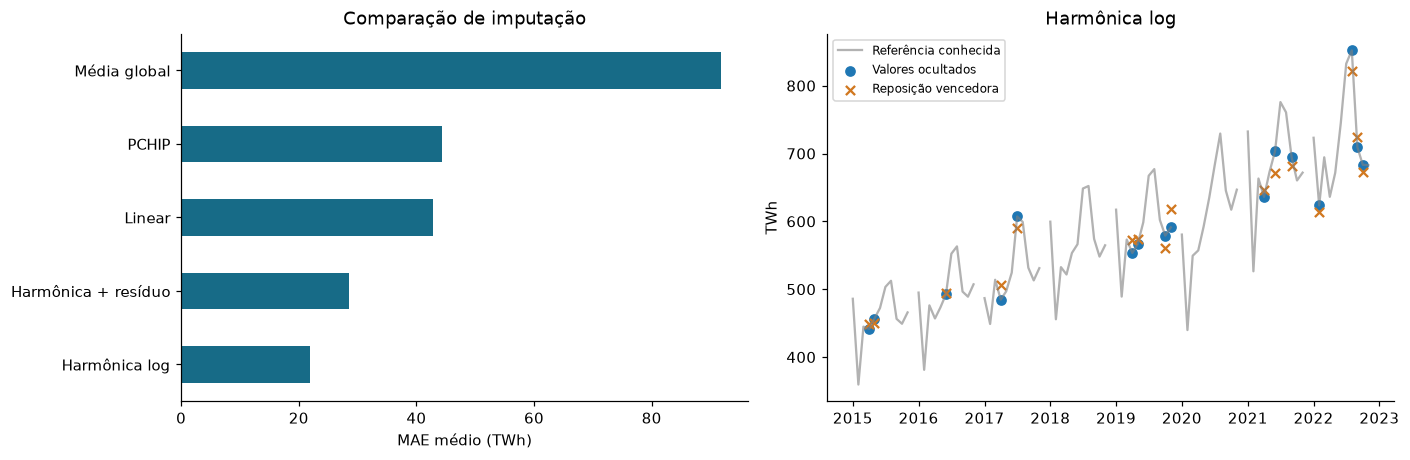

In [5]:
rng = np.random.default_rng(SEMENTE + 1)
apagadas_exemplo = sortear_mascara(periodo_experimento, elegiveis, 'Aleatório 20%', rng)
entrada_exemplo = ocultar(periodo_experimento, apagadas_exemplo)
exemplo = pd.DataFrame({'Real (TWh)': periodo_experimento.loc[apagadas_exemplo]})
for metodo in METODOS:
    exemplo[metodo] = imputar(entrada_exemplo, metodo).loc[apagadas_exemplo]
exemplo['Erro absoluto do vencedor'] = (exemplo[melhor_imputador]-exemplo['Real (TWh)']).abs()
tabela(exemplo, '09_exemplo_reposicoes')
fig, axs = plt.subplots(1,2,figsize=(13,4.3))
ranking.MAE_medio.sort_values().plot.barh(ax=axs[0], color='#176B87')
axs[0].set(title='Comparação de imputação', xlabel='MAE médio (TWh)', ylabel='')
axs[1].plot(periodo_experimento, color='gray', alpha=.6, label='Referência conhecida')
axs[1].scatter(apagadas_exemplo, exemplo['Real (TWh)'], marker='o', label='Valores ocultados')
axs[1].scatter(apagadas_exemplo, exemplo[melhor_imputador], marker='x', color='#D17820', label='Reposição vencedora')
axs[1].set(title=melhor_imputador, ylabel='TWh'); axs[1].legend(fontsize=8)
figura('02_imputacao')

## 3. Série de trabalho: preencher as 12 lacunas originais
Agora ajustamos o método escolhido aos **108 valores disponíveis de toda a série** e preenchemos somente os 12 valores ausentes. Isso produz uma série de trabalho para análise retrospectiva, mantendo intactos os valores conhecidos.

**Limite do experimento:** nenhum dezembro estava disponível para ser ocultado. Assim, o erro observado nos testes não mede diretamente a qualidade das estimativas de dezembro. Mesmo um método que vence nos meses conhecidos depende de hipóteses para estimar um mês nunca observado. Também não impomos igualdade com acumulados de versões diferentes. A diferença para os agregados oficiais é apresentada como diagnóstico.

Criamos ainda uma alternativa por interpolação linear para verificar se as conclusões dos testes de estacionariedade mudam com o preenchimento. Imputação simples não propaga toda a incerteza: os testes seguintes devem ser lidos **condicionalmente ao preenchimento escolhido**.

In [6]:
trabalho = imputar(serie, melhor_imputador)
alternativa_linear = imputar(serie, 'Linear')
procedencia = dados.status.copy()
procedencia.loc[lacunas_originais] = 'imputado_' + melhor_imputador
preenchimento = pd.DataFrame({'Original': serie, 'Trabalho (TWh)': trabalho,
                             'Alternativa linear': alternativa_linear, 'Procedência': procedencia})
tabela(preenchimento.loc[lacunas_originais], '10_lacunas_originais_preenchidas')
reconciliacao = pd.DataFrame({'Total NEA': anuais,
    'Soma série de trabalho': trabalho.groupby(trabalho.index.year).sum()})
reconciliacao['Diferença (TWh)'] = reconciliacao['Soma série de trabalho']-reconciliacao['Total NEA']
reconciliacao['Diferença (%)'] = 100*reconciliacao['Diferença (TWh)']/reconciliacao['Total NEA']
tabela(reconciliacao, '11_comparacao_agregados')
print('Bimestre jan–fev/2024 estimado:', round(trabalho.loc['2024-01':'2024-02'].sum(),2),
      'TWh; divulgado: 1531,6 TWh. Os valores não foram forçados a coincidir.')

,Original,Trabalho (TWh),Alternativa linear,Procedência
data,,,,
2015-12-01,NaN,506.538,480.40,imputado_Harmônica log
2016-12-01,NaN,539.341,497.00,imputado_Harmônica log
2017-12-01,NaN,574.269,565.25,imputado_Harmônica log
2018-12-01,NaN,611.459,590.95,imputado_Harmônica log
2019-12-01,NaN,651.058,585.85,imputado_Harmônica log
2020-12-01,NaN,693.221,689.55,imputado_Harmônica log
2021-12-01,NaN,738.114,697.50,imputado_Harmônica log
2022-12-01,NaN,785.915,685.60,imputado_Harmônica log
2023-12-01,NaN,836.811,770.80,imputado_Harmônica log


,Total NEA,Soma série de trabalho,Diferença (TWh),Diferença (%)
2015,5550.0,5554.238,4.238,0.076
2016,5919.8,5922.241,2.441,0.041
2017,6307.7,6311.669,3.969,0.063
2018,6844.9,6828.059,-16.841,-0.246
2019,7225.5,7165.558,-59.942,-0.830
2020,7511.0,7368.721,-142.279,-1.894
2021,8312.8,8235.114,-77.686,-0.935
2022,8637.2,8639.715,2.515,0.029
2023,9224.1,9205.411,-18.689,-0.203
2024,9852.1,9819.629,-32.471,-0.330


Bimestre jan–fev/2024 estimado: 1486.53 TWh; divulgado: 1531,6 TWh. Os valores não foram forçados a coincidir.


## 4. Estacionariedade: o comportamento estatístico muda com o tempo?
Uma série é **fracamente estacionária** quando sua média e sua variância são constantes ao longo do tempo e a relação entre dois valores depende da distância entre eles, não da data em si. Um consumo que cresce continuamente não oscila em torno de uma média fixa.

Não estacionariedade não significa “dados ruins”. Significa que certos modelos exigem transformações ou componentes explícitos para descrever a mudança. Holt e Holt-Winters, por exemplo, modelam nível, tendência e sazonalidade e não exigem que a série original seja estacionária.

### Dois testes com hipóteses opostas
| Teste | Hipótese nula ($H_0$) | Se p < 0,05 |
|---|---|---|
| ADF — Dickey-Fuller aumentado | Existe raiz unitária, uma forma de não estacionariedade. | Rejeitamos raiz unitária na especificação utilizada. |
| KPSS | A série é estacionária em torno do componente determinístico especificado. | Rejeitamos essa estacionariedade. |

**Raiz unitária**, em termos simples, é uma situação em que um choque pode deixar efeito persistente no nível. O ADF investiga se há evidência contra esse comportamento. O KPSS parte da hipótese oposta. “Não rejeitar” uma hipótese **não é provar** que ela é verdadeira.

Usamos nível de significância de 5%, fixado antes dos resultados. Com `c`, a referência é uma constante; com `ct`, admite-se uma tendência linear determinística. Estacionária **em torno de uma tendência** não significa estacionária em nível sem retirar essa tendência.

| Resultado conjunto | Leitura cuidadosa |
|---|---|
| ADF rejeita; KPSS não rejeita | Evidência compatível com estacionariedade na especificação. |
| ADF não rejeita; KPSS rejeita | Evidência compatível com não estacionariedade. |
| Ambos rejeitam | Resultados divergentes: investigar quebras, especificação e sazonalidade. |
| Nenhum rejeita | Evidência inconclusiva; os testes podem ter pouco poder. |

### Transformações comparadas
- **Logaritmo:** $z_t=\log y_t$. Coloca mudanças proporcionais em escala comparável; não garante estacionariedade.
- **Primeira diferença:** $\Delta z_t=z_t-z_{t-1}$. Aproxima a taxa mensal de crescimento; multiplique por 100 para porcentagem aproximada.
- **Diferença sazonal:** $\Delta_{12}z_t=z_t-z_{t-12}$. Compara o mesmo mês de anos consecutivos.
- **Diferença comum e sazonal:** $\Delta\Delta_{12}z_t$. Combina as duas operações. Diferenciar demais também pode prejudicar o modelo; não se escolhe uma transformação apenas para obter p pequeno.

No ADF, o número de defasagens é escolhido por AIC entre 0 e 12. No KPSS, usamos a seleção automática da biblioteca. Apresentamos ambos os números. Os p-valores tabelados do KPSS são limitados: `≤0,01` e `≥0,10` indicam limites, não valores exatos.

**Referências:** [ADF](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html), [KPSS](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.kpss.html). Esses testes não são testes específicos de raiz unitária sazonal nem substituem o exame dos gráficos.

,Preenchimento,Transformação,Regressão,N,ADF estatística,ADF p,ADF lags,ADF crítico 5%,KPSS estatística,KPSS p,KPSS lags,KPSS crítico 5%,Leitura a 5%
0,Harmônica log,Nível,c,120,1.395,0.997,12,-2.889,1.749,"≤0,01",6,0.463,Compatível com não estacionariedade
1,Harmônica log,Log nível,c,120,-0.168,0.942,12,-2.889,1.763,"≤0,01",6,0.463,Compatível com não estacionariedade
2,Harmônica log,Log com tendência,ct,120,-2.008,0.597,12,-3.452,0.024,"≥0,10",1,0.146,Inconclusivo
3,Harmônica log,Diferença log,c,119,-4.595,0.000,12,-2.889,0.122,"≥0,10",21,0.463,Compatível com estacionariedade na especificação
4,Harmônica log,Diferença sazonal log,c,108,-4.784,0.000,1,-2.889,0.058,"≥0,10",4,0.463,Compatível com estacionariedade na especificação
5,Harmônica log,Diferença comum + sazonal log,c,107,-9.571,0.000,2,-2.890,0.050,"≥0,10",9,0.463,Compatível com estacionariedade na especificação
6,Linear (sensibilidade),Nível,c,120,0.788,0.991,12,-2.889,1.725,"≤0,01",6,0.463,Compatível com não estacionariedade
7,Linear (sensibilidade),Log nível,c,120,-0.301,0.925,12,-2.889,1.743,"≤0,01",6,0.463,Compatível com não estacionariedade
8,Linear (sensibilidade),Log com tendência,ct,120,-2.392,0.384,12,-3.452,0.023,"≥0,10",3,0.146,Inconclusivo
9,Linear (sensibilidade),Diferença log,c,119,-5.180,0.000,11,-2.889,0.049,"≥0,10",9,0.463,Compatível com estacionariedade na especificação


Leitura principal em log nível: Compatível com não estacionariedade
Compare as mesmas transformações entre os dois preenchimentos antes de concluir.


**Neste conjunto:** no log em nível, ADF p = 0.9423 e KPSS p ≤0,01. Os dois apontam para não estacionariedade em nível. Para a diferença sazonal do log, ADF p = 0.000058 e KPSS p ≥0,10: o resultado é compatível com estacionariedade na especificação. A primeira diferença também passa nos critérios, e a inclusão apenas de tendência deixa os testes inconclusivos. As mesmas leituras qualitativas aparecem com preenchimento linear. **Uma escolha didática útil é estudar a diferença de 12 meses do log**, que compara cada mês ao mesmo mês do ano anterior; não é necessário acrescentar outra diferença somente para diminuir o p-valor.

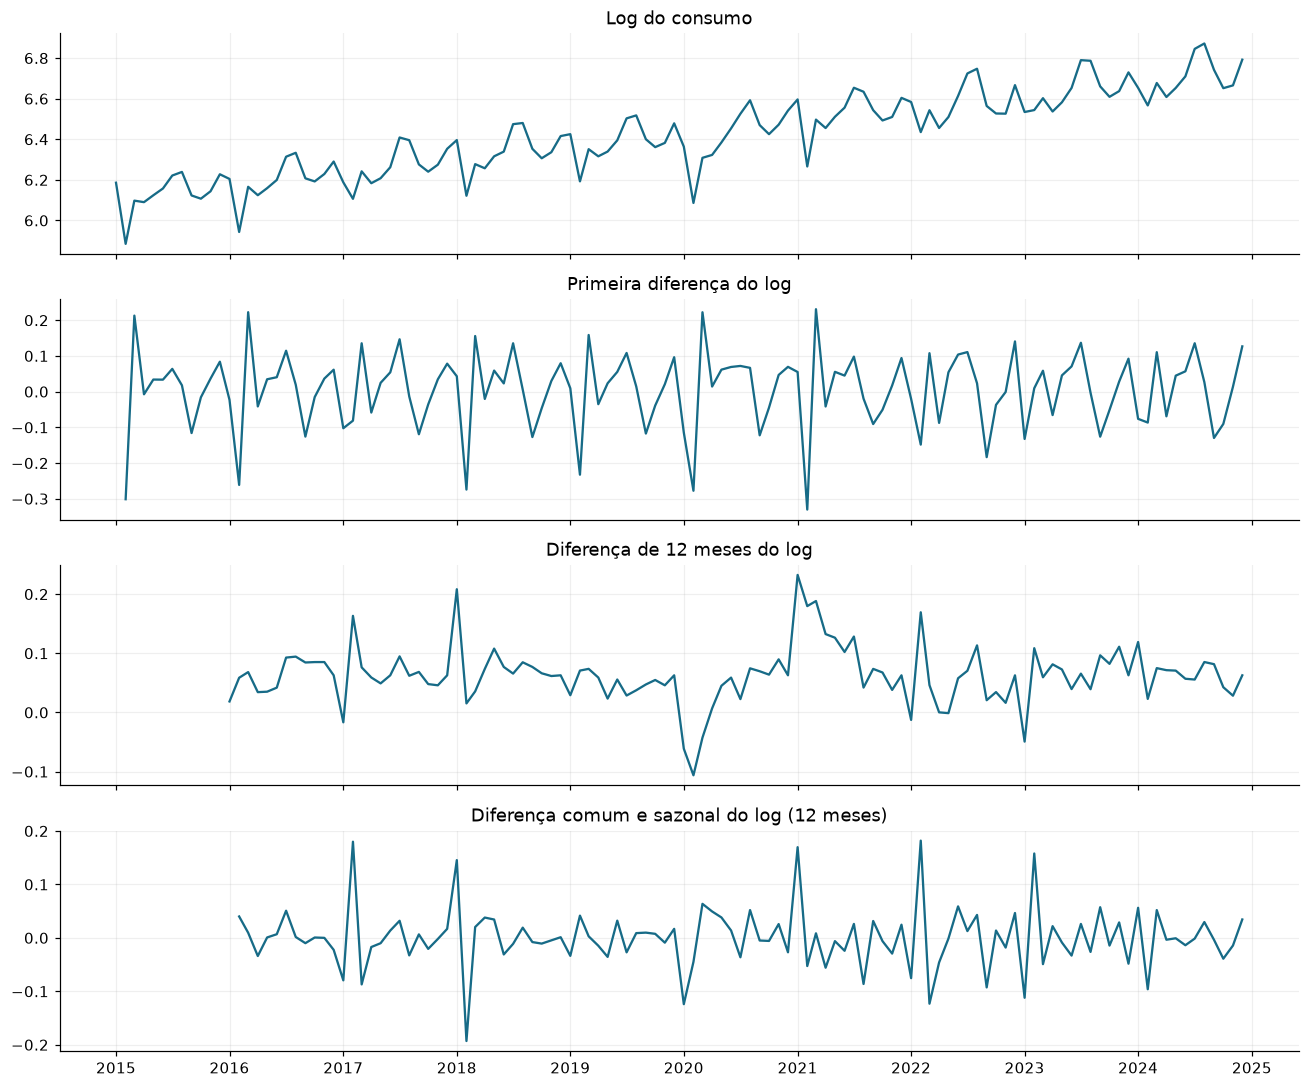

In [7]:
def leitura_testes(p_adf, p_kpss):
    a, k = p_adf < .05, p_kpss < .05
    if a and not k: return 'Compatível com estacionariedade na especificação'
    if not a and k: return 'Compatível com não estacionariedade'
    if a and k: return 'Testes divergentes: investigar especificação'
    return 'Inconclusivo'

def testar(s, identificacao):
    z = np.log(s)
    versoes = [('Nível', s, 'c'), ('Log nível', z, 'c'), ('Log com tendência', z, 'ct'),
               ('Diferença log', z.diff(), 'c'), ('Diferença sazonal log', z.diff(12), 'c'),
               ('Diferença comum + sazonal log', z.diff(12).diff(), 'c')]
    linhas = []
    for nome, v, reg in versoes:
        v = v.dropna()  # Apenas perdas iniciais causadas por diferenças; calendário já está completo.
        opcao_adf = {'result_object': False} if 'result_object' in inspect.signature(adfuller).parameters else {}
        adf = adfuller(v, maxlag=12, regression=reg, autolag='AIC', **opcao_adf)
        with warnings.catch_warnings(record=True) as avisos:
            warnings.simplefilter('always')
            opcao_kpss = {'result_object': False} if 'result_object' in inspect.signature(kpss).parameters else {}
            kp = kpss(v, regression=reg, nlags='auto', **opcao_kpss)
        p_txt = '≤0,01' if kp[1] <= .01 else ('≥0,10' if kp[1] >= .1 else f'{kp[1]:.4f}')
        linhas.append({'Preenchimento': identificacao, 'Transformação': nome, 'Regressão': reg,
            'N': len(v), 'ADF estatística': adf[0], 'ADF p': adf[1], 'ADF lags': adf[2],
            'ADF crítico 5%': adf[4]['5%'], 'KPSS estatística': kp[0], 'KPSS p': p_txt,
            'KPSS lags': kp[2], 'KPSS crítico 5%': kp[3]['5%'],
            'Leitura a 5%': leitura_testes(adf[1], kp[1]),
            'Aviso KPSS': ' | '.join(str(w.message) for w in avisos)})
    return pd.DataFrame(linhas)

testes = pd.concat([testar(trabalho, melhor_imputador), testar(alternativa_linear, 'Linear (sensibilidade)')], ignore_index=True)
tabela(testes.drop(columns='Aviso KPSS'), '12_testes_estacionariedade')
testes.to_csv(SAIDA/'12_testes_com_avisos.csv', index=False)
print('Leitura principal em log nível:', testes.iloc[1]['Leitura a 5%'])
print('Compare as mesmas transformações entre os dois preenchimentos antes de concluir.')
principal_est = testes[testes.Preenchimento.eq(melhor_imputador)].set_index('Transformação')
r_nivel = principal_est.loc['Log nível']
r_dif = principal_est.loc['Diferença sazonal log']
display(Markdown(f"**Neste conjunto:** no log em nível, ADF p = {r_nivel['ADF p']:.4f} e KPSS p {r_nivel['KPSS p']}. Os dois apontam para não estacionariedade em nível. Para a diferença sazonal do log, ADF p = {r_dif['ADF p']:.6f} e KPSS p {r_dif['KPSS p']}: o resultado é compatível com estacionariedade na especificação. A primeira diferença também passa nos critérios, e a inclusão apenas de tendência deixa os testes inconclusivos. As mesmas leituras qualitativas aparecem com preenchimento linear. **Uma escolha didática útil é estudar a diferença de 12 meses do log**, que compara cada mês ao mesmo mês do ano anterior; não é necessário acrescentar outra diferença somente para diminuir o p-valor."))
fig, axs = plt.subplots(4,1,figsize=(12,10),sharex=True)
for ax, s, titulo in zip(axs, [np.log(trabalho), np.log(trabalho).diff(), np.log(trabalho).diff(12),
                             np.log(trabalho).diff(12).diff()],
                        ['Log do consumo', 'Primeira diferença do log', 'Diferença de 12 meses do log',
                         'Diferença comum e sazonal do log (12 meses)']):
    ax.plot(s, color='#176B87'); ax.set_title(titulo); ax.grid(alpha=.2)
figura('03_transformacoes_estacionariedade')

## 5. Outliers: valores estranhos em relação ao comportamento esperado
Um **outlier** é um valor muito distante do padrão usado como referência. Um pico no verão pode ser normal; uma alta inesperada no meio de um período estável pode merecer investigação. Por isso, não aplicamos simplesmente um limite único ao consumo de toda a década.

### Detecção: STL robusta + mediana e MAD dos resíduos
A **STL** separa a série em tendência, sazonalidade e resíduo usando regressões locais suaves (**LOESS**). “Robusta” significa reduzir a influência de observações que se afastam muito do ajuste. Usamos o log do consumo, período 12, janela sazonal 13 e tendência 25 meses, fixados para o exercício.

$$\log y_t=T_t+S_t+r_t.$$
Nos resíduos, calculamos a mediana $m$ e o **MAD**, desvio absoluto mediano:
$$MAD=\operatorname{mediana}(|r_t-m|),\quad \widehat\sigma_r=1{,}4826\,MAD,\quad z_t^*=\frac{r_t-m}{\widehat\sigma_r}.$$
O fator 1,4826 torna a escala comparável ao desvio-padrão sob normalidade. Mediana e MAD sofrem menos influência de extremos que média e desvio-padrão.

Sinalizamos $|z_t^*|>3{,}5$. É uma **regra exploratória**, não um teste com falso positivo controlado. Pontos preenchidos e janeiros reconstituídos não são classificados como outliers observados; entram no ajuste, mas a sinalização e a escala usam apenas os valores diretamente publicados. Nas extremidades e perto de lacunas, a interpretação é ainda mais incerta.

### Tratamento dos suspeitos originais
Sem prova de erro de registro, preservamos os números oficiais. Para cumprir o exercício, criamos uma **cópia tratada por winsorização dos resíduos**: um resíduo além do limite é trazido até o limite mais próximo. Isso altera menos o ponto que substituí-lo inteiramente pela tendência e sazonalidade. É uma análise de sensibilidade, **não uma correção factual da NEA**.

[Referência da STL](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.STL.html).

,Original disponível,Escore robusto,Cópia tratada (TWh),Alteração (TWh)
data,,,,
2017-02-01,448.8,6.001,435.606,-13.194
2020-02-01,439.8,-14.628,502.249,62.449
2020-03-01,549.3,-8.483,582.951,33.651
2020-07-01,682.4,-4.785,692.943,10.543
2021-02-01,526.4,-7.235,550.392,23.992
2023-02-01,695.0,4.430,687.332,-7.668


Suspeitos diretamente observados: 6
Esses sinais não comprovam erros. As estimativas de lacunas podem influenciar a detecção.


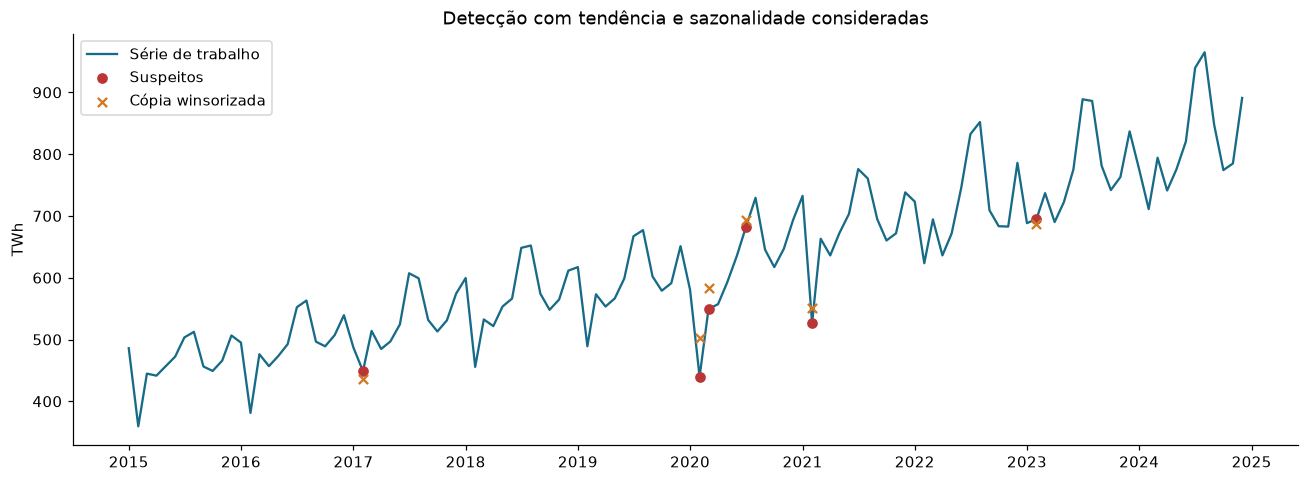

In [8]:
def detectar(s, elegivel):
    elegivel = elegivel.reindex(s.index).fillna(False).astype(bool)
    decom = STL(np.log(s), period=12, seasonal=13, trend=25, robust=True).fit()
    residuo = pd.Series(decom.resid, index=s.index)
    m = residuo[elegivel].median()
    mad = (residuo[elegivel]-m).abs().median()
    escala = max(1.4826*mad, 1e-8)
    z = (residuo-m)/escala
    flags = z.abs().gt(3.5) & elegivel
    esperado = pd.Series(decom.trend+decom.seasonal, index=s.index)
    return {'flags': flags, 'residuo': residuo, 'mediana': m, 'escala': escala,
            'z': z, 'esperado': esperado, 'stl': decom}

def tratar(s, deteccao, metodo):
    f = deteccao['flags']; saida = s.copy()
    m, escala = deteccao['mediana'], deteccao['escala']
    if metodo == 'Sem tratamento': return saida
    if metodo == 'Winsorizar resíduos':
        r = deteccao['residuo'].clip(m-3.5*escala, m+3.5*escala)
        estimado = np.exp(deteccao['esperado']+r)
    elif metodo == 'Reconstrução STL':
        estimado = np.exp(deteccao['esperado']+m)
    elif metodo == 'Remover e imputar':
        estimado = imputar(s.mask(f), melhor_imputador)
    else: raise ValueError(metodo)
    saida.loc[f] = estimado.loc[f]
    np.testing.assert_array_equal(saida[~f], s[~f])
    return saida

deteccao_original = detectar(trabalho, diretos)
suspeitos = deteccao_original['flags']
tratada = tratar(trabalho, deteccao_original, 'Winsorizar resíduos')
quadro_suspeitos = pd.DataFrame({'Original disponível': serie, 'Escore robusto': deteccao_original['z'],
                               'Cópia tratada (TWh)': tratada})
quadro_suspeitos['Alteração (TWh)'] = tratada-serie
tabela(quadro_suspeitos.loc[suspeitos], '13_outliers_suspeitos_e_tratamento')
print('Suspeitos diretamente observados:', int(suspeitos.sum()))
print('Esses sinais não comprovam erros. As estimativas de lacunas podem influenciar a detecção.')
fig, ax = plt.subplots()
ax.plot(trabalho, label='Série de trabalho', color='#176B87')
ax.scatter(trabalho.index[suspeitos], trabalho[suspeitos], color='#BA3636', label='Suspeitos', zorder=4)
ax.scatter(tratada.index[suspeitos], tratada[suspeitos], marker='x', color='#D17820', label='Cópia winsorizada', zorder=5)
ax.set(title='Detecção com tendência e sazonalidade consideradas', ylabel='TWh'); ax.legend()
figura('04_outliers_originais')

### Experimento controlado com outliers artificiais
Os suspeitos reais não têm uma “resposta correta” alternativa conhecida. Por isso, **também criamos erros artificiais**, mesmo se houver suspeitos reais. Se nenhum ponto fosse sinalizado, esse experimento ainda permitiria cumprir a atividade.

Selecionamos seis valores diretamente publicados, fora da lista de suspeitos e longe das pontas. Guardamos seus valores, multiplicamos três por fatores acima de 2 e três por fatores abaixo de 0,4, e executamos novamente o detector **sem informar os locais das alterações**.

Comparamos quatro opções: não tratar; winsorizar resíduos; reconstruir o componente esperado pela STL; remover os pontos detectados e imputar. O tratamento só age onde o detector sinaliza: um outlier artificial não detectado continua prejudicando o resultado.

**Precisão** = fração dos sinais do detector que coincide com uma alteração artificial. **Sensibilidade (recall)** = fração das seis alterações encontradas. Para essa avaliação, excluímos os suspeitos já existentes, pois não sabemos se eram erros. Um “falso positivo” aqui é um alarme fora das seis alterações no domínio avaliado, não uma afirmação de que o valor oficial é correto.

Além do erro nas seis posições, medimos alterações desnecessárias nos outros pontos avaliáveis, para não premiar um método que conserta alguns valores e distorce muitos outros. Este é um cenário fixo de erros grandes e isolados; resultados podem mudar para erros menores, blocos ou mudanças permanentes de nível.

{'Alterações artificiais': 6, 'Verdadeiros positivos': 6, 'Falsos positivos no domínio': 1, 'Falsos negativos': 0, 'Precisão': 0.8571428571428571, 'Recall': 1.0}


,MAE,RMSE,MAPE (%),MAE demais pontos,MAE todo domínio
Método,,,,,
Reconstrução STL,7.048,8.074,1.158,0.392,0.821
Remover e imputar,15.539,18.004,2.814,0.229,1.217
Winsorizar resíduos,30.023,31.804,4.833,0.009,1.946
Sem tratamento,676.208,758.267,110.000,0.000,43.626


,Referência,Fator,Contaminado,Detectado,Sem tratamento,Winsorizar resíduos,Reconstrução STL,Remover e imputar
2016-03-01,476.2,2.50,1190.500,True,1190.500,489.965,469.447,447.621
2016-10-01,489.0,0.30,146.700,True,146.700,460.158,480.270,465.705
2018-04-01,521.7,2.20,1147.740,True,1147.740,546.183,523.311,528.522
2021-06-01,703.3,0.35,246.155,True,246.155,662.635,691.597,682.234
2021-07-01,775.8,2.80,2172.240,True,2172.240,821.341,786.946,767.599
2021-09-01,694.7,0.25,173.675,True,173.675,667.856,697.045,689.427


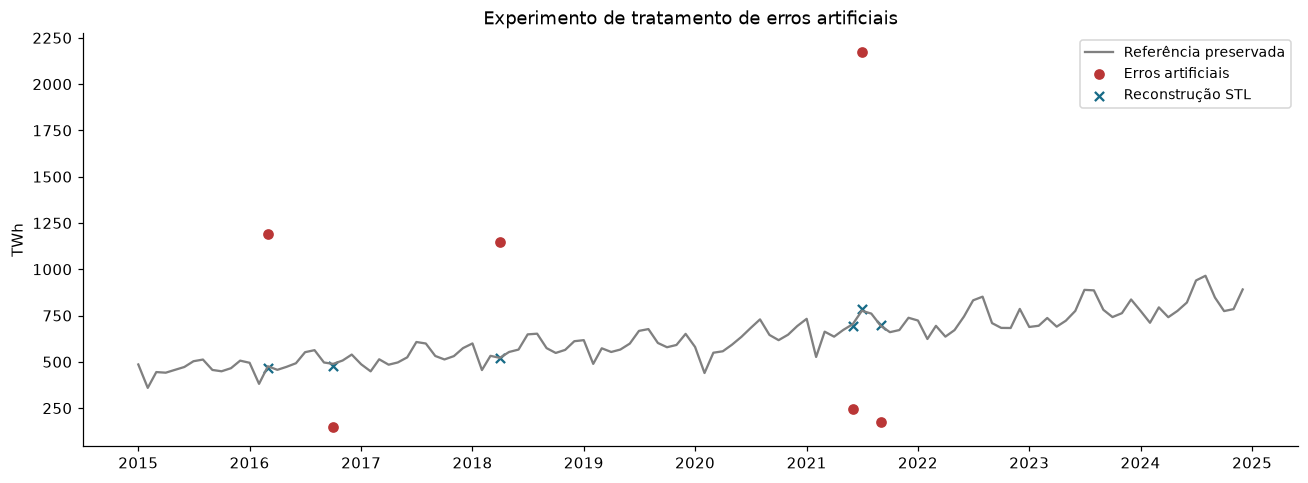

In [9]:
rng = np.random.default_rng(SEMENTE+9000)
dominio = diretos & ~suspeitos
candidatos = trabalho.index[dominio & (trabalho.index.year >= 2016) & (trabalho.index.year <= 2023)]
injetados = pd.DatetimeIndex(sorted(rng.choice(candidatos, size=6, replace=False)))
fatores = np.array([2.5, .30, 2.2, .35, 2.8, .25])
contaminada = trabalho.copy(); contaminada.loc[injetados] *= fatores
artificial = pd.Series(False, index=trabalho.index); artificial.loc[injetados] = True
det_artificial = detectar(contaminada, diretos)
marcados = det_artificial['flags']
tp = int((marcados & artificial & dominio).sum())
fp = int((marcados & ~artificial & dominio).sum())
fn = int((~marcados & artificial & dominio).sum())
print({'Alterações artificiais': 6, 'Verdadeiros positivos': tp, 'Falsos positivos no domínio': fp,
       'Falsos negativos': fn, 'Precisão': tp/(tp+fp) if tp+fp else np.nan, 'Recall': tp/6})
metodos_outliers = ['Sem tratamento', 'Winsorizar resíduos', 'Reconstrução STL', 'Remover e imputar']
resultados_outliers = {}; linhas = []
for nome in metodos_outliers:
    corrigida = tratar(contaminada, det_artificial, nome)
    resultados_outliers[nome] = corrigida
    medidas = metricas(trabalho.loc[injetados], corrigida.loc[injetados])
    intactos = dominio & ~artificial
    linhas.append({'Método': nome, **medidas,
        'MAE demais pontos': (corrigida[intactos]-trabalho[intactos]).abs().mean(),
        'MAE todo domínio': (corrigida[dominio]-trabalho[dominio]).abs().mean()})
comparacao_outliers = pd.DataFrame(linhas).set_index('Método').sort_values('MAE')
tabela(comparacao_outliers, '14_comparacao_tratamentos_outliers')
melhor_outlier = comparacao_outliers.index[0]
ex_out = pd.DataFrame({'Referência': trabalho.loc[injetados], 'Fator': fatores,
                      'Contaminado': contaminada.loc[injetados], 'Detectado': marcados.loc[injetados]})
for nome, s in resultados_outliers.items(): ex_out[nome] = s.loc[injetados]
tabela(ex_out, '15_outliers_artificiais_valores')
fig, ax = plt.subplots()
ax.plot(trabalho, color='gray', label='Referência preservada')
ax.scatter(injetados, contaminada.loc[injetados], color='#BA3636', label='Erros artificiais')
ax.scatter(injetados, resultados_outliers[melhor_outlier].loc[injetados], marker='x', color='#176B87', label=melhor_outlier)
ax.set(title='Experimento de tratamento de erros artificiais', ylabel='TWh'); ax.legend(fontsize=9)
figura('05_outliers_artificiais')

## 6. Média móvel, tendência, sazonalidade e ciclo
### Média móvel
Uma média móvel substitui cada ponto pela média de uma janela próxima. Ela reduz oscilações curtas e ajuda a enxergar o movimento geral.

A média móvel **trailing** de $k$ meses usa o mês atual e os $k-1$ anteriores:
$$MM_k(t)=\frac1k\sum_{j=0}^{k-1}y_{t-j}.$$
Com $k=3$, a média em março usa janeiro, fevereiro e março. Janelas maiores suavizam mais e respondem mais lentamente a mudanças. Exigimos janelas completas: os primeiros $k-1$ resultados ficam ausentes.

A média móvel **centrada 2×12**, comum em dados mensais, primeiro calcula médias de 12 meses e depois centraliza com uma média de duas delas. Seus pesos são 1/24 nas pontas $t-6$ e $t+6$ e 1/12 nos onze pontos interiores. Ela usa observações futuras: serve para descrição histórica, não para previsão em tempo real.

Abaixo, “cópia tratada” significa apenas o tratamento didático dos suspeitos; os outliers artificiais **não entram** nos cálculos finais. Como essa série foi preenchida e tratada retrospectivamente, até a média trailing calculada nela não representa uma informação histórica disponível em tempo real.

,Trabalho,Cópia tratada,MM3,MM6,MM12,MM centrada 2x12
data,,,,,,
2023-07-01,888.800,888.800,795.367,750.072,741.846,770.105
2023-08-01,886.100,886.100,850.000,783.200,744.687,774.721
2023-09-01,781.100,781.100,852.000,790.567,750.679,778.099
2023-10-01,741.900,741.900,803.033,799.200,755.554,782.616
2023-11-01,763.000,763.000,762.000,806.000,762.237,786.949
2023-12-01,836.811,836.811,780.570,816.285,766.479,791.045
2024-01-01,775.423,775.423,791.745,797.389,773.731,795.053
2024-02-01,711.103,711.103,774.446,768.223,775.711,800.453
2024-03-01,794.200,794.200,760.242,770.406,780.486,806.503


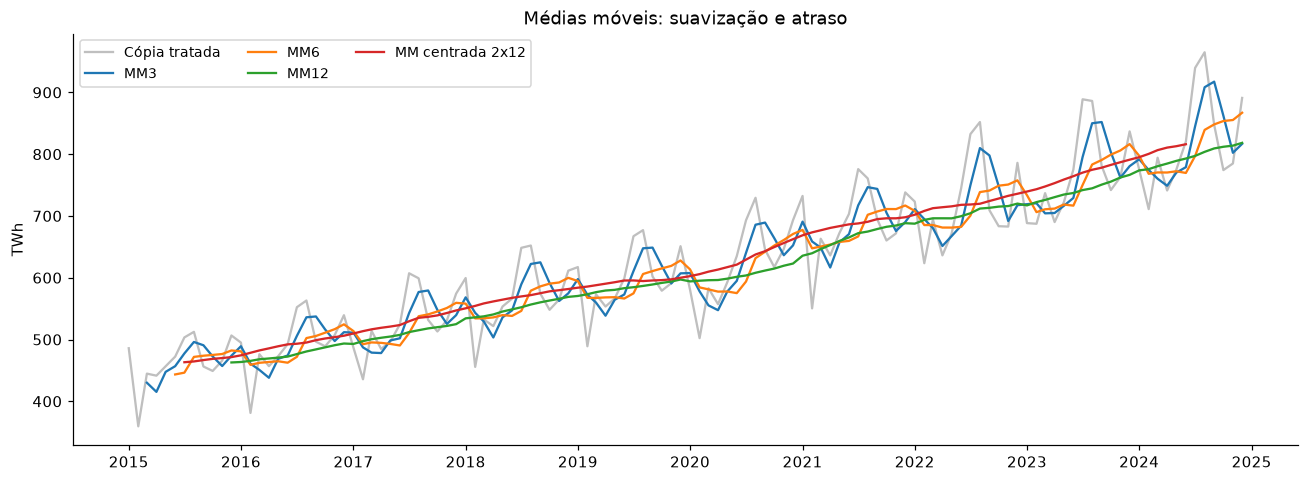

In [10]:
movel = pd.DataFrame({'Trabalho': trabalho, 'Cópia tratada': tratada})
for k in [3,6,12]: movel[f'MM{k}'] = tratada.rolling(k, min_periods=k).mean()
pesos = np.r_[.5, np.ones(11), .5]/12
movel['MM centrada 2x12'] = tratada.rolling(13, center=True).apply(lambda v: np.dot(v,pesos), raw=True)
assert np.isclose(pesos.sum(), 1)
assert movel.MM12.isna().sum() == 11 and movel['MM centrada 2x12'].isna().sum() == 12
tabela(movel.tail(18), '16_medias_moveis_amostra')
movel.to_csv(SAIDA/'16_medias_moveis_completas.csv')
fig, ax = plt.subplots()
ax.plot(tratada, color='gray', alpha=.5, label='Cópia tratada')
for col in ['MM3','MM6','MM12','MM centrada 2x12']: ax.plot(movel[col], label=col)
ax.set(title='Médias móveis: suavização e atraso', ylabel='TWh'); ax.legend(ncol=3,fontsize=9)
figura('06_medias_moveis')

### Quatro componentes diferentes
| Componente | Significado | Exemplo intuitivo |
|---|---|---|
| Tendência ($T$) | Movimento de longo prazo. | Crescimento do consumo ao longo dos anos. |
| Sazonalidade ($S$) | Padrão ligado ao calendário, com período regular. | Consumo maior em julho/agosto. |
| Ciclo ($C$) | Oscilação mais lenta em torno da tendência, sem período fixo obrigatório. | Expansões e desacelerações prolongadas. |
| Resíduo ($R$) | Parte não explicada pelos componentes escolhidos. | Choques, ruído, erros e efeitos não modelados. |

**Ciclo não é sinônimo de sazonalidade nem de resíduo.** Sua separação da tendência depende do método; não existe uma única decomposição verdadeira observável.

Usamos STL robusta em **TWh**, nesta seção, para manter uma decomposição aditiva de interpretação simples:
$$y_t=TC_t+S_t+R_t.$$
A STL produz uma componente suave que chamamos de **tendência-ciclo ($TC$)**. Para separar movimentos mais longos, aplicamos o filtro **Hodrick–Prescott (HP)** a $TC$:
$$TC_t=T_t+C_t,\qquad y_t=T_t+C_t+S_t+R_t.$$

O HP procura uma tendência próxima aos dados, mas penaliza mudanças bruscas em sua inclinação:
$$\min_T\sum_t(TC_t-T_t)^2+\lambda\sum_t[(T_{t+1}-T_t)-(T_t-T_{t-1})]^2.$$
Quanto maior $\lambda$, mais lisa a tendência. Usamos **129.600**, convenção mensal derivada de $1600(12/4)^4$. Aplicá-lo à componente suave da STL deixa no ciclo apenas variações suaves; o resíduo irregular permanece separado. Essa combinação é uma **escolha descritiva**, não uma identificação comprovada do ciclo econômico da China.

O HP pode produzir oscilações artificiais e é sensível às extremidades e a $\lambda$. Exibimos uma comparação com metade e o dobro do parâmetro. Tanto a STL quanto o HP usam a amostra histórica completa. A sazonalidade de dezembro depende especialmente da imputação, pois esse mês não foi observado.

[Referência do HP e da escolha mensal de $\lambda$](https://www.statsmodels.org/stable/generated/statsmodels.tsa.filters.hp_filter.hpfilter.html).

,Consumo tratado,Tendência,Ciclo,Sazonalidade,Resíduo,Tendência-ciclo STL
data,,,,,,
2023-07-01,888.800,771.506,-1.455,112.406,6.344,770.051
2023-08-01,886.100,775.233,-0.861,124.701,-12.973,774.371
2023-09-01,781.100,778.964,-0.286,8.652,-6.230,778.678
2023-10-01,741.900,782.699,0.273,-49.360,8.289,782.971
2023-11-01,763.000,786.437,0.861,-36.209,11.911,787.297
2023-12-01,836.811,790.178,1.465,45.099,0.069,791.643
2024-01-01,775.423,793.922,1.922,-12.152,-8.269,795.844
2024-02-01,711.103,797.668,2.300,-87.510,-1.356,799.968
2024-03-01,794.200,801.416,2.658,-14.375,4.501,804.074


,mean,min,max,Observações mensais diretas
data,,,,
1,16.862,-12.152,31.948,0
2,-91.956,-93.995,-87.510,9
3,-12.868,-14.818,-8.161,10
4,-45.427,-69.653,-20.083,10
5,-27.205,-42.976,-7.116,10
6,6.406,1.196,12.370,10
7,84.309,48.248,120.708,10
8,90.991,50.249,135.056,10
9,0.696,-8.360,11.268,10


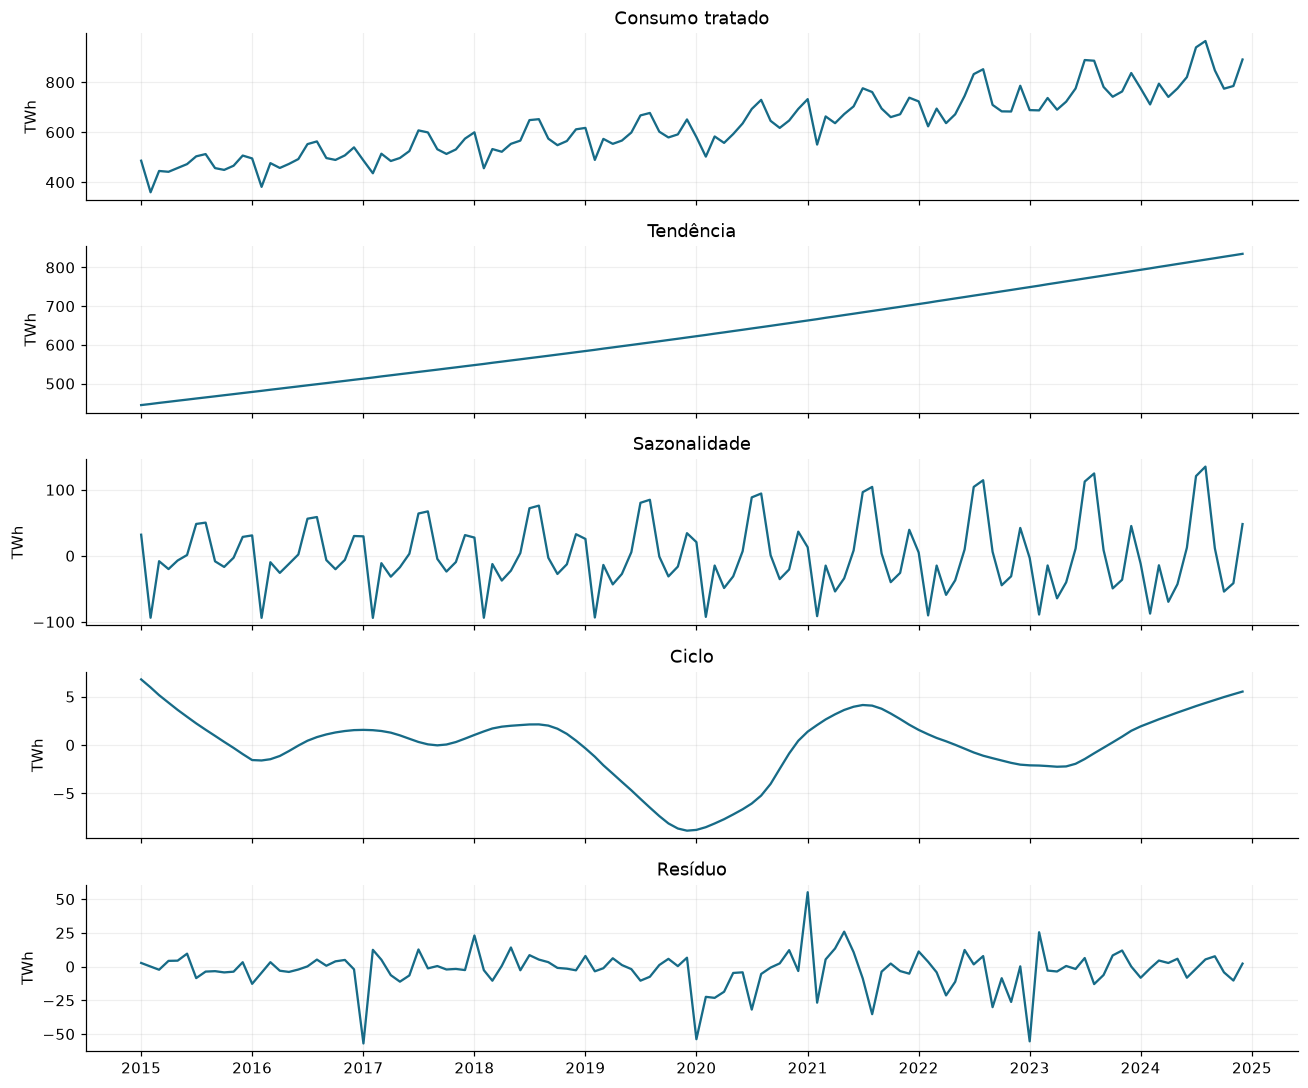

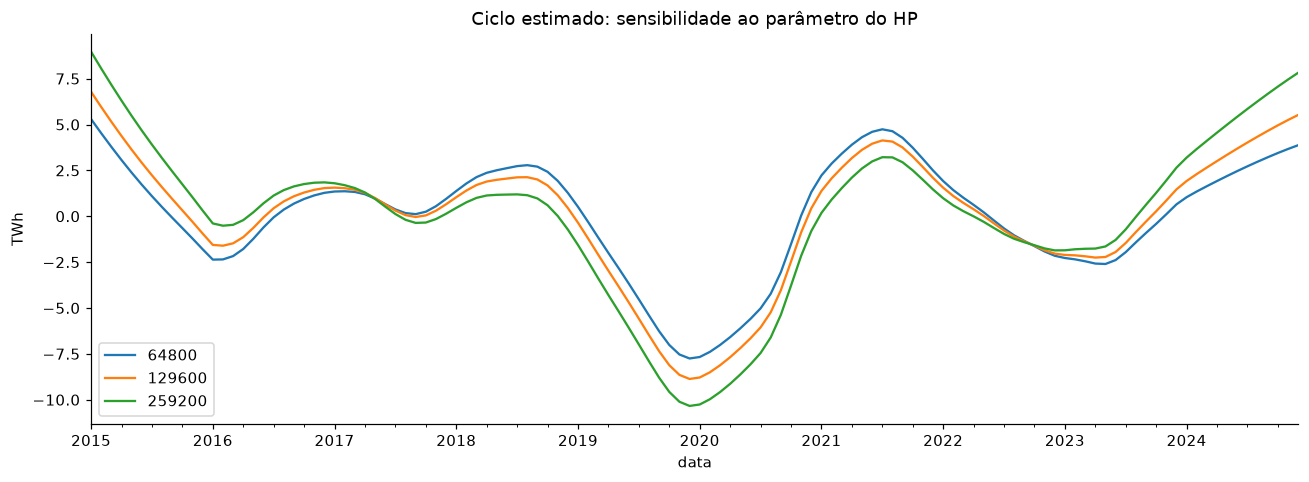

In [11]:
dec = STL(tratada, period=12, seasonal=13, trend=25, robust=True).fit()
tc = pd.Series(dec.trend, index=tratada.index)
ciclo, tendencia = hpfilter(tc, lamb=129600)
componentes = pd.DataFrame({'Consumo tratado': tratada, 'Tendência': tendencia, 'Ciclo': ciclo,
                           'Sazonalidade': dec.seasonal, 'Resíduo': dec.resid, 'Tendência-ciclo STL': tc})
reconstruida = componentes[['Tendência','Ciclo','Sazonalidade','Resíduo']].sum(axis=1)
np.testing.assert_allclose(reconstruida, tratada, atol=1e-8)
tabela(componentes.tail(18), '17_componentes_amostra')
componentes.to_csv(SAIDA/'17_componentes_completos.csv')
perfil_sazonal = componentes.Sazonalidade.groupby(componentes.index.month).agg(['mean','min','max'])
perfil_sazonal['Observações mensais diretas'] = diretos.groupby(diretos.index.month).sum()
tabela(perfil_sazonal, '18_sazonalidade_por_mes')
fig, axs = plt.subplots(5,1,figsize=(12,10),sharex=True)
for ax, col in zip(axs, ['Consumo tratado','Tendência','Sazonalidade','Ciclo','Resíduo']):
    ax.plot(componentes[col], color='#176B87'); ax.set_ylabel('TWh'); ax.set_title(col); ax.grid(alpha=.2)
figura('07_decomposicao')

sensibilidade_ciclo = pd.DataFrame(index=tratada.index)
for lam in [64800,129600,259200]:
    c, t = hpfilter(tc, lamb=lam); sensibilidade_ciclo[str(lam)] = c
sensibilidade_ciclo.to_csv(SAIDA/'19_sensibilidade_ciclo.csv')
ax = sensibilidade_ciclo.plot(title='Ciclo estimado: sensibilidade ao parâmetro do HP', ylabel='TWh')
figura('08_sensibilidade_ciclo')

## 7. Suavização exponencial: Holt e Holt-Winters
**Suavizar** é atualizar uma estimativa do comportamento da série, dando pesos aos dados. Na suavização exponencial, a influência das observações antigas diminui progressivamente. Isso difere de uma média móvel, que descarta totalmente valores fora da janela.

### Holt: nível e tendência
Holt atualiza um **nível** $\ell_t$ (patamar atual) e uma **tendência** $b_t$ (mudança por mês):
$$\ell_t=\alpha y_t+(1-\alpha)(\ell_{t-1}+b_{t-1}),$$
$$b_t=\beta(\ell_t-\ell_{t-1})+(1-\beta)b_{t-1},\qquad \widehat y_{t+h}=\ell_t+h b_t.$$
$\alpha$ controla a velocidade de atualização do nível; $\beta$, a da tendência. Valores altos reagem mais rapidamente. Valores baixos produzem mais estabilidade. **Holt não inclui sazonalidade**, portanto é uma comparação importante para esta série.

### Holt-Winters: nível, tendência e sazonalidade
Holt-Winters acrescenta $s_t$, um fator ou desvio sazonal, com período $m=12$.

**Versão aditiva:** adequada quando a amplitude sazonal é aproximadamente constante em TWh.
$$\ell_t=\alpha(y_t-s_{t-m})+(1-\alpha)(\ell_{t-1}+b_{t-1}),$$
$$b_t=\beta(\ell_t-\ell_{t-1})+(1-\beta)b_{t-1},$$
$$s_t=\gamma(y_t-\ell_{t-1}-b_{t-1})+(1-\gamma)s_{t-m},$$
$$\widehat y_{t+h}=\ell_t+h b_t+s_{t+h-m(k+1)},\quad k=\lfloor(h-1)/m\rfloor.$$
A equação sazonal acima usa o nível previsto no passo anterior, convenção da implementação utilizada.

**Versão multiplicativa:** adequada quando a amplitude cresce proporcionalmente ao nível; exige valores positivos.
$$\ell_t=\alpha\frac{y_t}{s_{t-m}}+(1-\alpha)(\ell_{t-1}+b_{t-1}),$$
$$b_t=\beta(\ell_t-\ell_{t-1})+(1-\beta)b_{t-1},$$
$$s_t=\gamma\frac{y_t}{\ell_{t-1}+b_{t-1}}+(1-\gamma)s_{t-m},$$
$$\widehat y_{t+h}=(\ell_t+h b_t)\,s_{t+h-m(k+1)}.$$
Um fator sazonal de 1,10 representa 10% acima do nível previsto. $\gamma$ controla a atualização da sazonalidade. Nas duas versões usadas aqui a **tendência é aditiva e não amortecida**; “multiplicativa” refere-se ao componente sazonal.

Os parâmetros e os estados iniciais são estimados numericamente por mínimos quadrados não lineares (`least_squares`) para reduzir o erro de ajuste. A tabela exibirá $\alpha$, $\beta$ e $\gamma$, e eventuais avisos do otimizador. Um parâmetro próximo de zero pode indicar um componente quase fixo, não ausência obrigatória dele.

**Referências:** [Holt](https://www.statsmodels.org/stable/generated/statsmodels.tsa.holtwinters.Holt.html), [Holt-Winters](https://www.statsmodels.org/stable/generated/statsmodels.tsa.holtwinters.ExponentialSmoothing.html).

### Avaliação temporal: prever sem olhar o futuro
1. **Treino 2015–2022 → validação 2023:** comparamos Holt, Holt-Winters aditivo, Holt-Winters multiplicativo e uma referência sazonal ingênua ($\widehat y_t=y_{t-12}$). Escolhemos o menor MAE de validação.
2. **Treino 2015–2023 → teste 2024:** reestimamos cada modelo com o período ampliado e mostramos o resultado, mantendo a escolha feita em 2023. Não escolhemos novamente pelo teste.
3. Em cada treino, o preenchimento e o tratamento de suspeitos são **refeitos só com dados daquele treino**. Não utilizamos a série completada com toda a década para prever 2023 ou 2024.
4. O erro é calculado somente nos meses de validação/teste **diretamente publicados**. Janeiro reconstituído e meses ausentes são excluídos da avaliação. O teste de 2024 cobre março–novembro, não o ano completo.

A referência sazonal pode usar um mês imputado no treino; isso é identificado como limitação. A hipótese didática é que as publicações do treino já estavam disponíveis no instante da previsão. Esta não é uma simulação exata de tempo real: não modelamos atrasos de publicação nem revisões de cada versão histórica.

,Etapa,N avaliado,MAE,RMSE,MAPE (%)
Modelo,,,,,
Holt-Winters aditivo,Validação,10,25.086,33.691,3.244
Holt-Winters multiplicativo,Validação,10,29.907,39.928,3.926
Holt,Validação,10,46.364,64.478,5.748
Sazonal ingênuo,Validação,10,58.964,63.230,7.830


,Etapa,N avaliado,MAE,RMSE,MAPE (%),Escolhido na validação
Modelo,,,,,,
Sazonal ingênuo,Teste,9,50.767,53.204,6.093,False
Holt,Teste,9,55.903,76.159,6.371,False
Holt-Winters aditivo,Teste,9,18.843,24.487,2.159,True
Holt-Winters multiplicativo,Teste,9,16.453,21.722,1.889,False


alpha  beta     gamma
Etapa     Modelo                                               
Validação Holt                         0.000000   0.0       NaN
          Holt-Winters aditivo         0.220553   0.0  0.299235
          Holt-Winters multiplicativo  0.310732   0.0  0.000000
Teste     Holt                         0.000000   0.0       NaN
          Holt-Winters aditivo         0.163140   0.0  0.284091
          Holt-Winters multiplicativo  0.176226   0.0  0.000000

Modelo escolhido antes de examinar o teste: Holt-Winters aditivo
O ranking de teste não redefine a escolha.


**Leitura da comparação:** Holt-Winters aditivo foi escolhido pela validação. No teste de 2024, o menor MAE descritivo foi de Holt-Winters multiplicativo (16.45 TWh). Mostrar esse resultado é informativo, mas trocar a escolha depois de olhar o teste transformaria o teste em mais uma etapa de seleção. O resultado oficial do procedimento continua sendo o do modelo escolhido em 2023.

,Original 2024,Avaliado,Sazonal ingênuo,Holt,Holt-Winters aditivo,Holt-Winters multiplicativo
data,,,,,,
2024-01-01,NaN,False,688.40,781.711,794.901,804.536
2024-02-01,NaN,False,695.00,784.942,716.752,675.809
2024-03-01,794.2,True,736.90,788.172,784.839,776.521
2024-04-01,741.2,True,690.10,791.402,748.228,737.852
2024-05-01,775.1,True,722.20,794.632,779.999,770.685
2024-06-01,820.5,True,775.10,797.862,826.915,817.863
2024-07-01,939.6,True,888.80,801.092,910.189,915.045
2024-08-01,964.9,True,886.10,804.322,912.092,922.737
2024-09-01,847.5,True,781.10,807.552,812.700,811.022


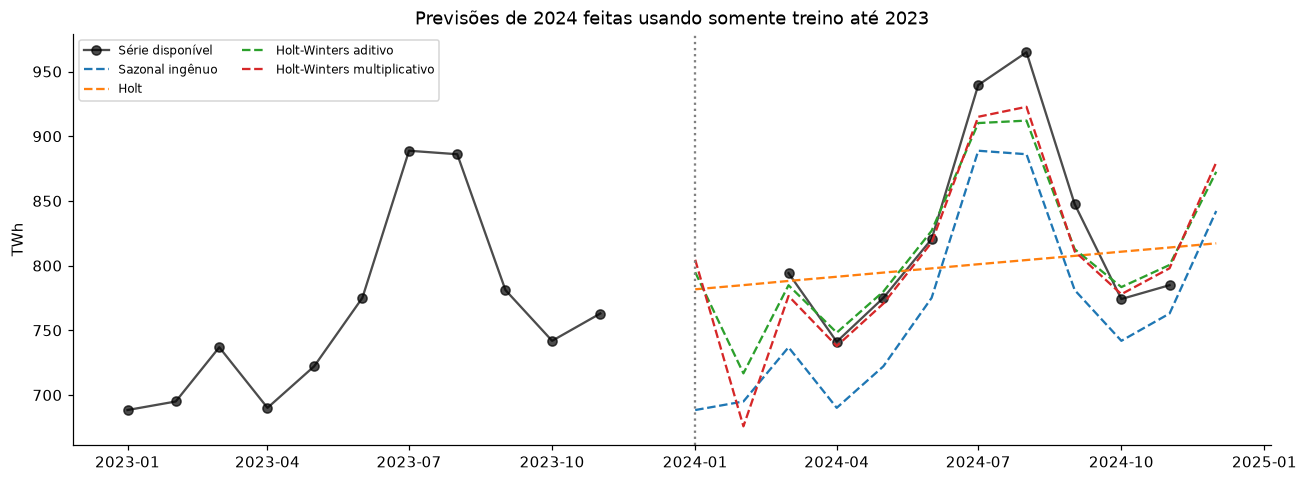

In [12]:
MODELOS = ['Sazonal ingênuo', 'Holt', 'Holt-Winters aditivo', 'Holt-Winters multiplicativo']
avisos_modelos = []

def preparar_treino(s):
    # Não acessa datas posteriores ao fim de s.
    completa = imputar(s, melhor_imputador)
    det = detectar(completa, diretos.reindex(s.index))
    return tratar(completa, det, 'Winsorizar resíduos')

def ajustar_prever(s, nome, horizonte=12, etapa=''):
    if nome == 'Sazonal ingênuo':
        ind = pd.date_range(s.index[-1]+pd.offsets.MonthBegin(), periods=horizonte, freq='MS')
        return None, pd.Series(np.resize(s.iloc[-12:].to_numpy(), horizonte), index=ind)
    # Escala numérica menor facilita a otimização; saída é reconvertida a TWh.
    y = s/1000
    with warnings.catch_warnings(record=True) as ws:
        warnings.simplefilter('always')
        if nome == 'Holt':
            fit = Holt(y, initialization_method='estimated').fit(optimized=True, method='least_squares')
        else:
            saz = 'add' if nome.endswith('aditivo') else 'mul'
            fit = ExponentialSmoothing(y, trend='add', seasonal=saz, seasonal_periods=12,
                initialization_method='estimated').fit(optimized=True, use_brute=True, method='least_squares')
    sucesso = getattr(fit, 'mle_retvals', {}).get('success', True)
    for w in ws: avisos_modelos.append({'Etapa': etapa, 'Modelo': nome, 'Aviso': str(w.message)})
    if not sucesso: avisos_modelos.append({'Etapa': etapa, 'Modelo': nome, 'Aviso': 'Otimizador não declarou convergência.'})
    return fit, fit.forecast(horizonte)*1000

avaliacoes = []; previsoes = {}; ajustes = {}; parametros = []
for fim, ano, etapa in [('2022-12-01',2023,'Validação'), ('2023-12-01',2024,'Teste')]:
    treino = preparar_treino(serie.loc[:fim])
    alvo = serie.loc[str(ano)]; elegivel = diretos.loc[str(ano)]
    for nome in MODELOS:
        fit, pred = ajustar_prever(treino, nome, etapa=etapa)
        assert pred.index.equals(alvo.index)
        resultado = metricas(alvo[elegivel], pred[elegivel])
        avaliacoes.append({'Etapa': etapa, 'Modelo': nome, 'N avaliado': int(elegivel.sum()), **resultado})
        previsoes[(etapa,nome)] = pred; ajustes[(etapa,nome)] = fit
        if fit is not None:
            parametros.append({'Etapa': etapa, 'Modelo': nome,
                'alpha': fit.params['smoothing_level'], 'beta': fit.params['smoothing_trend'],
                'gamma': fit.params.get('smoothing_seasonal', np.nan)})
avaliacoes = pd.DataFrame(avaliacoes)
validacao = avaliacoes[avaliacoes.Etapa.eq('Validação')].set_index('Modelo').sort_values('MAE')
modelo_escolhido = validacao.index[0]
teste = avaliacoes[avaliacoes.Etapa.eq('Teste')].set_index('Modelo')
teste['Escolhido na validação'] = teste.index == modelo_escolhido
tabela(validacao, '20_comparacao_validacao_2023')
tabela(teste, '21_comparacao_teste_2024')
tabela(pd.DataFrame(parametros).set_index(['Etapa','Modelo']), '22_parametros_suavizacao', casas=6)
print('Modelo escolhido antes de examinar o teste:', modelo_escolhido)
print('O ranking de teste não redefine a escolha.')
melhor_no_teste = teste.MAE.idxmin()
display(Markdown(f"**Leitura da comparação:** {modelo_escolhido} foi escolhido pela validação. No teste de 2024, o menor MAE descritivo foi de {melhor_no_teste} ({teste.loc[melhor_no_teste, 'MAE']:.2f} TWh). Mostrar esse resultado é informativo, mas trocar a escolha depois de olhar o teste transformaria o teste em mais uma etapa de seleção. O resultado oficial do procedimento continua sendo o do modelo escolhido em 2023."))

quadro_previsoes = pd.DataFrame({'Original 2024': serie.loc['2024'], 'Avaliado': diretos.loc['2024']})
for nome in MODELOS: quadro_previsoes[nome] = previsoes[('Teste',nome)]
tabela(quadro_previsoes, '23_previsoes_2024')
fig, ax = plt.subplots()
ax.plot(serie.loc['2023':], 'o-', color='black', label='Série disponível', alpha=.7)
for nome in MODELOS: ax.plot(previsoes[('Teste',nome)], '--', label=nome)
ax.axvline(pd.Timestamp('2024-01-01'), color='gray', linestyle=':')
ax.set(title='Previsões de 2024 feitas usando somente treino até 2023', ylabel='TWh')
ax.legend(fontsize=8,ncol=2)
figura('09_previsoes_teste')

### Ajustes suavizados e estados estimados na década completa
Por fim, ajustamos Holt e as duas versões de Holt-Winters à cópia tratada de toda a década para mostrar os valores ajustados, o nível, a tendência e a sazonalidade estimados. Essa é uma visualização retrospectiva; seu erro dentro da amostra não substitui o teste temporal anterior.

O valor ajustado é uma previsão de um passo à frente usando os estados anteriores do modelo. Os parâmetros, porém, foram estimados usando a amostra completa. O nível é medido em TWh e a tendência em TWh por mês. A sazonalidade aditiva está em TWh; a multiplicativa é um fator sem unidade.

,alpha,beta,gamma
Modelo,,,
Holt,0.000000,0.0,NaN
Holt-Winters aditivo,0.145146,0.0,0.404602
Holt-Winters multiplicativo,0.186759,0.0,0.000000


,Holt | nível TWh,Holt | tendência TWh/mês,Holt-Winters aditivo | nível TWh,Holt-Winters aditivo | tendência TWh/mês,Holt-Winters aditivo | sazonalidade,Holt-Winters multiplicativo | nível TWh,Holt-Winters multiplicativo | tendência TWh/mês,Holt-Winters multiplicativo | sazonalidade
data,,,,,,,,
2024-01-01,787.261,3.318,-47943.973,3.258,48724.530,777.404,3.196,1.023
2024-02-01,790.579,3.318,-47941.591,3.258,48655.411,788.587,3.196,0.864
2024-03-01,793.897,3.318,-47936.765,3.258,48726.098,793.962,3.196,0.988
2024-04-01,797.215,3.318,-47933.792,3.258,48675.875,796.683,3.196,0.933
2024-05-01,800.533,3.318,-47930.742,3.258,48706.488,799.533,3.196,0.971
2024-06-01,803.851,3.318,-47928.505,3.258,48752.172,802.264,3.196,1.025
2024-07-01,807.169,3.318,-47921.915,3.258,48851.179,808.062,3.196,1.147
2024-08-01,810.487,3.318,-47912.310,3.258,48857.520,815.712,3.196,1.155
2024-09-01,813.805,3.318,-47905.312,3.258,48741.209,822.476,3.196,1.011


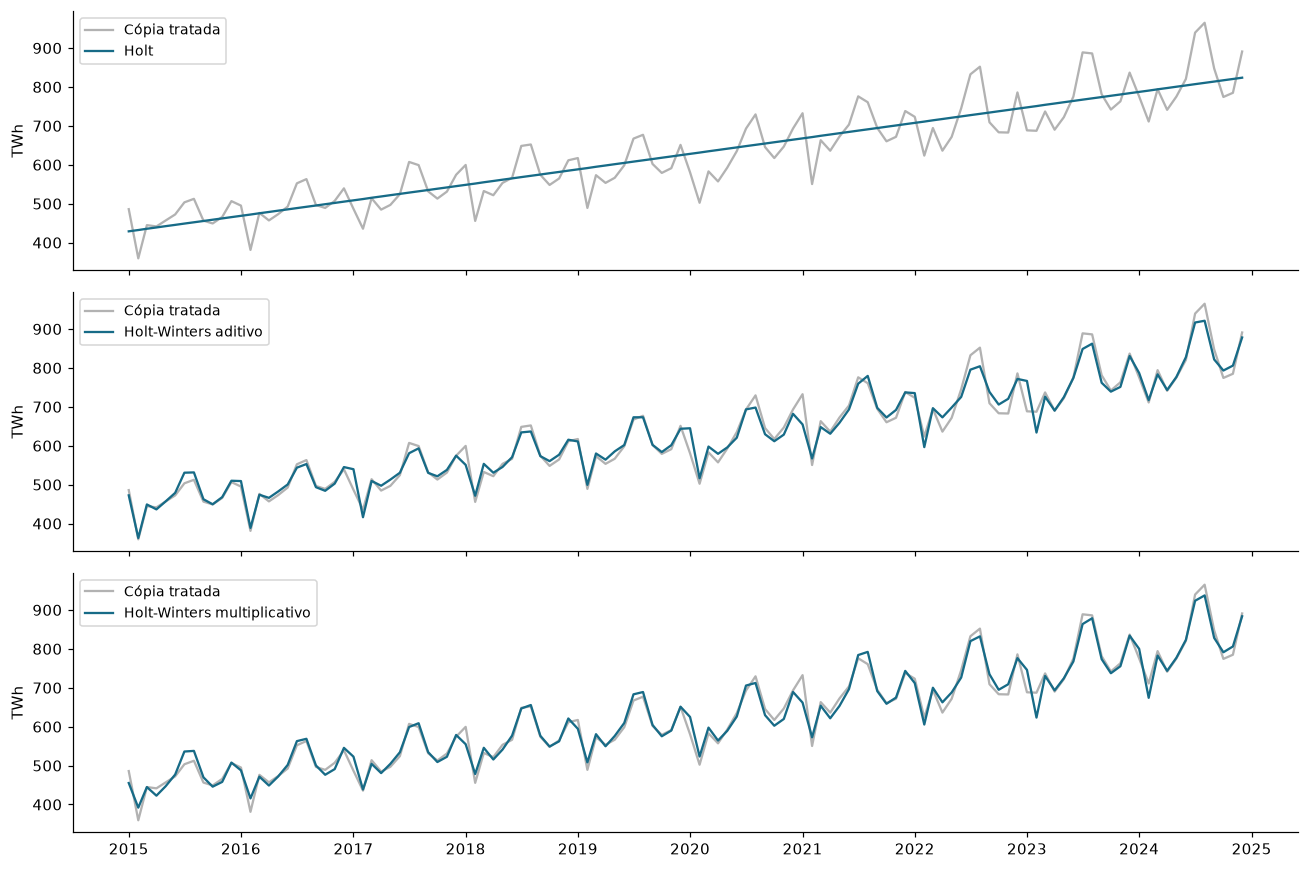

Ajustes sem avisos; otimizadores declararam convergência.


In [13]:
ajustes_completos = pd.DataFrame({'Série de trabalho': trabalho, 'Cópia tratada': tratada})
estados = pd.DataFrame(index=tratada.index)
parametros_finais = []
for nome in MODELOS[1:]:
    fit, _ = ajustar_prever(tratada, nome, etapa='Ajuste descritivo completo')
    ajustes_completos[nome] = fit.fittedvalues*1000
    estados[nome+' | nível TWh'] = fit.level*1000
    estados[nome+' | tendência TWh/mês'] = fit.trend*1000
    if 'Winters' in nome:
        estados[nome+' | sazonalidade'] = fit.season * (1000 if nome.endswith('aditivo') else 1)
    parametros_finais.append({'Modelo': nome, 'alpha': fit.params['smoothing_level'],
        'beta': fit.params['smoothing_trend'], 'gamma': fit.params.get('smoothing_seasonal',np.nan)})
tabela(pd.DataFrame(parametros_finais).set_index('Modelo'), '24_parametros_ajuste_completo', casas=6)
tabela(estados.tail(12), '25_estados_finais')
estados.to_csv(SAIDA/'25_estados_completos.csv')
ajustes_completos.to_csv(SAIDA/'26_ajustes_completos.csv')
fig, axs = plt.subplots(3,1,figsize=(12,8),sharex=True)
for ax, nome in zip(axs, MODELOS[1:]):
    ax.plot(tratada, color='gray', alpha=.6, label='Cópia tratada')
    ax.plot(ajustes_completos[nome], label=nome, color='#176B87')
    ax.set_ylabel('TWh'); ax.legend(fontsize=9)
figura('10_ajustes_suavizados')
pd.DataFrame(avisos_modelos, columns=['Etapa','Modelo','Aviso']).to_csv(SAIDA/'27_avisos_modelos.csv', index=False)
if avisos_modelos:
    tabela(pd.DataFrame(avisos_modelos), '27_avisos_modelos')
else:
    print('Ajustes sem avisos; otimizadores declararam convergência.')

## 8. Conclusões: o que os cálculos permitem afirmar?
O resumo abaixo é gerado a partir dos resultados efetivamente calculados. Isso evita escrever antecipadamente que um método “deveria” vencer. Um vencedor no experimento de imputação não é necessariamente o vencedor de previsão: são tarefas diferentes.

In [14]:
principal = testes[testes.Preenchimento.eq(melhor_imputador)]
mae_imp = ranking.loc[melhor_imputador,'MAE_medio']
mae_val = validacao.loc[modelo_escolhido,'MAE']
mae_teste = teste.loc[modelo_escolhido,'MAE']
texto = f"""**Imputação:** {melhor_imputador} teve o menor MAE médio nos cenários avaliados: **{mae_imp:.2f} TWh**. Isso não valida automaticamente dezembro, que nunca foi observado nesta coleta.

**Estacionariedade:** no log em nível, a leitura conjunta foi: **{principal.iloc[1]['Leitura a 5%']}**. Compare a tabela de diferenças e a alternativa linear; os testes não incorporam toda a incerteza da imputação.

**Outliers:** foram sinalizados **{int(suspeitos.sum())} valores diretamente publicados** como suspeitos, preservados na base oficial e winsorizados apenas em uma cópia de estudo. No experimento artificial, o detector encontrou **{tp} de 6** alterações. O menor MAE nas posições injetadas foi de **{melhor_outlier}**; confira também o erro nos demais pontos.

**Componentes:** a média móvel torna o movimento geral mais visível. A STL separa sazonalidade e resíduo; o HP divide a componente suave em tendência e ciclo estimados. A soma dos quatro componentes foi conferida numericamente. O ciclo é dependente do filtro, não uma prova de recessões ou expansões.

**Previsão:** a escolha pelo MAE de 2023 foi **{modelo_escolhido}** ({mae_val:.2f} TWh). Mantida essa escolha, o MAE nos **9 meses diretamente observados de 2024** foi **{mae_teste:.2f} TWh**. Esse número não representa o erro nos 12 meses de 2024.
"""
display(Markdown(texto))
(SAIDA/'conclusoes.md').write_text(texto)
base_final = pd.DataFrame({'Original disponível TWh': serie, 'Diretamente observado': diretos,
    'Lacuna original': lacunas_originais, 'Procedência': procedencia,
    'Série de trabalho TWh': trabalho, 'Suspeito observado': suspeitos,
    'Cópia tratada TWh': tratada})
base_final.to_csv(SAIDA/'28_base_final_com_mascaras.csv')
np.testing.assert_array_equal(trabalho[serie.notna()], serie.dropna())
assert trabalho.notna().all() and tratada.notna().all()
assert not (suspeitos & ~diretos).any()
assert experimentos.groupby(['Repetição','Cenário']).size().eq(len(METODOS)).all()
assert avaliacoes.groupby('Etapa')['N avaliado'].nunique().eq(1).all()
print('Verificações finais concluídas: observados preservados, calendário mensal, máscaras, unidades e decomposição consistentes.')
print('Resultados exportados para:', SAIDA)

**Imputação:** Harmônica log teve o menor MAE médio nos cenários avaliados: **21.92 TWh**. Isso não valida automaticamente dezembro, que nunca foi observado nesta coleta.

**Estacionariedade:** no log em nível, a leitura conjunta foi: **Compatível com não estacionariedade**. Compare a tabela de diferenças e a alternativa linear; os testes não incorporam toda a incerteza da imputação.

**Outliers:** foram sinalizados **6 valores diretamente publicados** como suspeitos, preservados na base oficial e winsorizados apenas em uma cópia de estudo. No experimento artificial, o detector encontrou **6 de 6** alterações. O menor MAE nas posições injetadas foi de **Reconstrução STL**; confira também o erro nos demais pontos.

**Componentes:** a média móvel torna o movimento geral mais visível. A STL separa sazonalidade e resíduo; o HP divide a componente suave em tendência e ciclo estimados. A soma dos quatro componentes foi conferida numericamente. O ciclo é dependente do filtro, não uma prova de recessões ou expansões.

**Previsão:** a escolha pelo MAE de 2023 foi **Holt-Winters aditivo** (25.09 TWh). Mantida essa escolha, o MAE nos **9 meses diretamente observados de 2024** foi **18.84 TWh**. Esse número não representa o erro nos 12 meses de 2024.


Verificações finais concluídas: observados preservados, calendário mensal, máscaras, unidades e decomposição consistentes.
Resultados exportados para: /Users/alex/Documents/ufpb-p5/econometria-2/exercicio1/resultados/energia_china


### Limitações para mencionar no trabalho
- A base reúne boletins de diferentes datas; não é uma série histórica perfeitamente harmonizada por revisão.
- As estatísticas originais descrevem 108 valores disponíveis, dos quais nove são reconstituições contábeis.
- As 12 imputações são hipóteses, sobretudo os dez dezembros sem observações de referência. O total bimestral e os totais anuais fornecem informação adicional não imposta nesta análise.
- ADF/KPSS não resolvem sozinhos sazonalidade, quebras estruturais ou mudanças na variância; os resultados podem mudar com a imputação e a especificação.
- A detecção de outliers depende da decomposição, da janela e do limite escolhido. Suspeito estatístico não é erro comprovado.
- Tendência e ciclo são estimativas dependentes de filtros, com maior incerteza nas pontas.
- A escolha de modelos usa um ano de validação e um ano de teste com cobertura parcial. Uma avaliação mais forte usaria várias origens de previsão e dados revisados de forma consistente.

**Para explicar em sala:** “Primeiro preservei os dados oficiais. Depois apaguei valores conhecidos para comparar reposições, mantendo as lacunas originais separadas. Completei uma série de trabalho, testei sua estacionariedade, sinalizei desvios em relação à tendência e à sazonalidade e comparei tratamentos em uma simulação. Por fim, calculei componentes e médias móveis e comparei Holt/Holt-Winters em períodos futuros separados do treino.”